In [40]:
import pandas as pd
import seaborn as sns
import os
import re
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import numpy as np
from matplotlib import pylab as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('train.csv')
df = df.sample(n=50000, random_state=42).copy(deep=True)
df.reset_index(drop=True, inplace=True)



print("shape:", df.shape)


print(df.head())


shape: (50000, 28)
        ID Customer_ID     Month         Name Age          SSN Occupation  \
0  0x1d1af  CUS_0x3539  February  an Arakalid  30  995-31-4669    Manager   
1  0x1ebd6  CUS_0x8716   January     Matthewz  18  185-99-8068  Scientist   
2   0x8a66  CUS_0x21dc   January   Tom Miless  41  241-53-8475  Developer   
3  0x1d769  CUS_0x32d3     April        Lisaa  35  204-78-6176    Manager   
4  0x236dd  CUS_0xadad    August       Masond  27  027-11-6852     Doctor   

  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  ...  Credit_Mix  \
0      43391.96            3688.996667                  1  ...        Good   
1      14351.21                    NaN                  8  ...         Bad   
2     130125.04           10871.753333                  5  ...        Good   
3      20107.21            1631.600833                  6  ...    Standard   
4      92186.19            7487.182500                  1  ...        Good   

   Outstanding_Debt Credit_Utilization_Ratio     

C:\Users\13761\AppData\Local\Temp\ipykernel_23832\2792131753.py:14: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train.csv')


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44956 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42572 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44263 non-null  object 
 14  Delay_

In [42]:
df.isnull().sum()      #credit_score is target value

ID                             0
Customer_ID                    0
Month                          0
Name                        5044
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7428
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                5737
Delay_from_due_date            0
Num_of_Delayed_Payment      3506
Changed_Credit_Limit           0
Num_Credit_Inquiries         990
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4534
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2224
Payment_Behaviour              0
Monthly_Balance              576
Credit_Score                   0
dtype: int64

Observations :
There are missing values present in dataset.
Dataset has both numerical and string values.

## EDA

In [43]:
df.describe()  # numerical

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,42572.000000,50000.000000,50000.00000,50000.000000,50000.000000,49010.000000,50000.000000,50000.000000
mean,4187.693841,16.648400,22.36360,71.266500,21.095440,28.355336,32.278797,1355.798538
std,3200.965026,115.230411,129.51885,461.151995,14.891104,198.002164,5.114205,8153.528676
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.100770,0.000000
25%,1616.786667,3.000000,4.00000,8.000000,10.000000,3.000000,28.052000,30.306610
50%,3073.482500,6.000000,5.00000,13.000000,18.000000,6.000000,32.307603,68.856718
75%,5936.870000,7.000000,7.00000,20.000000,28.000000,9.000000,36.478163,158.709886
max,15204.633333,1798.000000,1498.00000,5788.000000,67.000000,2597.000000,49.254983,82331.000000


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df['Credit_Score'].describe()  # categorical

count        50000
unique           3
top       Standard
freq         26576
Name: Credit_Score, dtype: object

In [46]:
print(df['Credit_Score'].value_counts())   # categorical

Credit_Score
Standard    26576
Poor        14461
Good         8963
Name: count, dtype: int64


In [47]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')  
import matplotlib.pyplot as plt


### Target’s Distribution

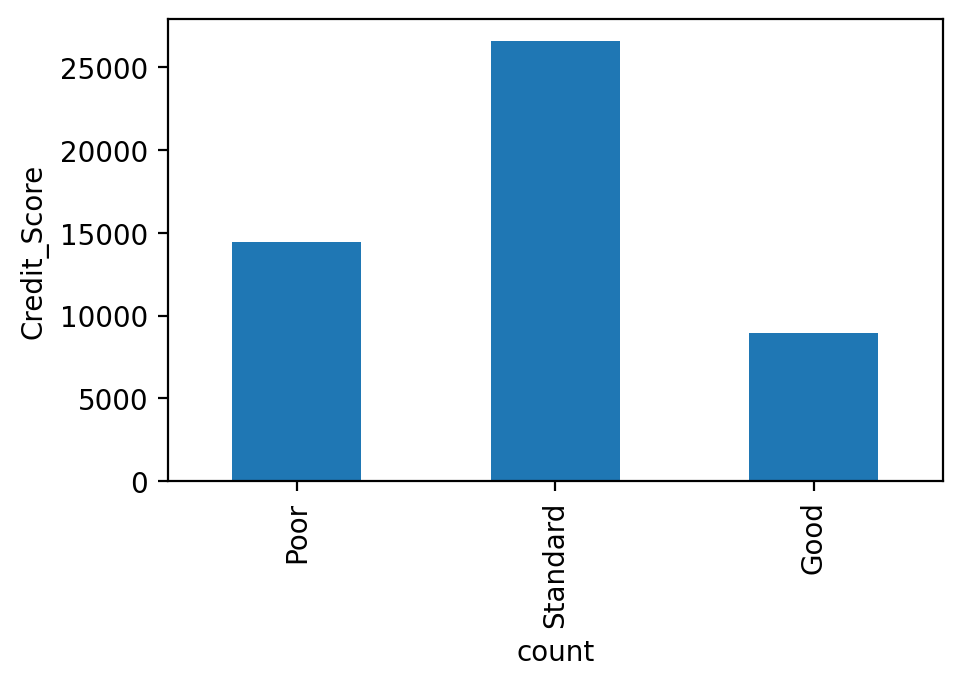

In [48]:
correct_ord = ['Poor','Standard','Good']
plt.figure(figsize=(5,3))
df['Credit_Score'].value_counts().reindex(correct_ord).plot.bar()
plt.xlabel('count')
plt.ylabel('Credit_Score')
plt.show()

In [49]:
#Check statistical values for fields with other than numerical datatype
df.describe(include="object").T

,count,unique,top,freq
ID,50000,50000,0x1d1af,1
Customer_ID,50000,12447,CUS_0xb4d6,8
Month,50000,8,June,6325
Name,44956,10067,Davidc,22
Age,50000,1014,26,1422
SSN,50000,12418,#F%$D@*&8,2784
Occupation,50000,16,_______,3499
Annual_Income,50000,15955,58317.0,8
Num_of_Loan,50000,267,2,7164
Type_of_Loan,44263,6235,Not Specified,675


## Observations

Customer_ID has 12447 unique values. It means we have data of 12447 customers.
Month has only 8 unique values. Better to analyse further which months are present.
Age has 1014 unique values. This looks strange as general age range is from 0-100.
SSN has 12418 unique values, whereas Customer_ID only has only 12447 unique values. 
 

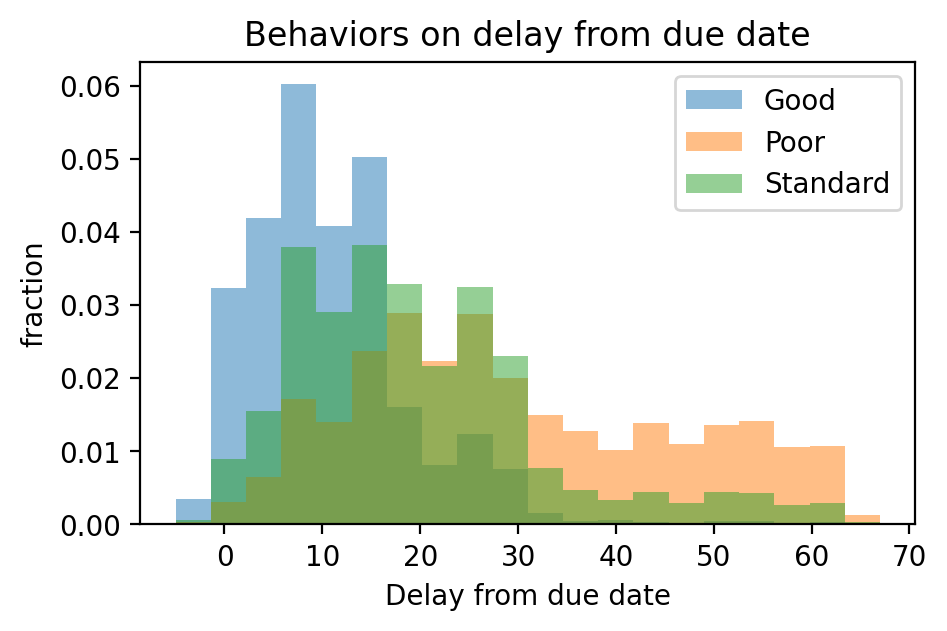

In [50]:
categories = df['Credit_Score'].unique()
bin_range = (df['Delay_from_due_date'].min(),df['Delay_from_due_date'].max())

plt.figure(figsize=(5,3))

for c in categories:
    plt.hist(df[df['Credit_Score']==c]['Delay_from_due_date'],alpha=0.5,label=c,range=bin_range,bins=20,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('Delay from due date')
plt.title('Behaviors on delay from due date')
plt.show()

In [51]:
payment delay is a strongest risk indicator.

Good credit customers rarely exceed 20 days delay.
Standard ones extend to 40 days.
Poor credit customers reach 70 days or more.

A 30-day delay threshold clearly separates good and bad credit, which became a key engineered feature.

SyntaxError: invalid syntax (2228550361.py, line 1)

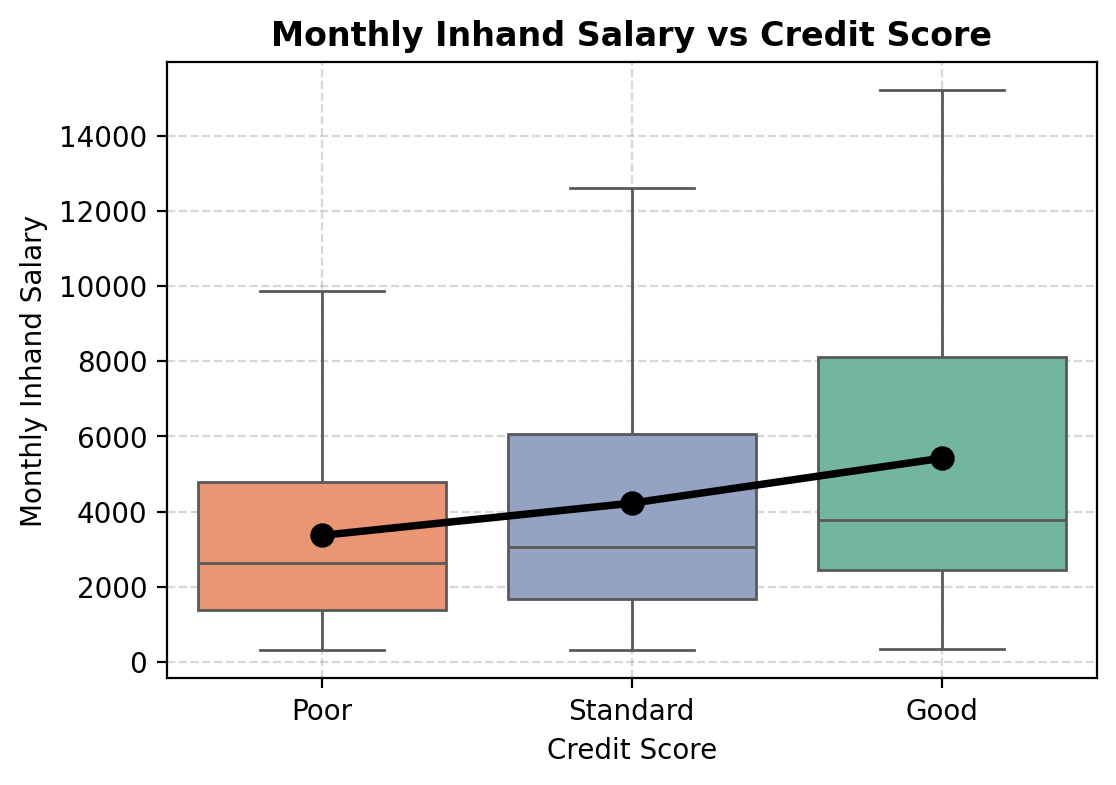

In [52]:
plt.figure(figsize=(6,4))
order = ['Poor', 'Standard', 'Good']
sns.boxplot(
    data=df,
    x='Credit_Score',
    y='Monthly_Inhand_Salary',
    hue='Credit_Score',  
    order=['Poor', 'Standard', 'Good'],# 新增这一行
    palette='Set2',
    showfliers=False,
    legend=False             # 不显示重复图例
)
sns.pointplot(
    data=df,
    x='Credit_Score',
    y='Monthly_Inhand_Salary',
    color='black',
    estimator='mean',
    errorbar=None
)
plt.title("Monthly Inhand Salary vs Credit Score", fontsize=12, fontweight='bold')
plt.xlabel("Credit Score")
plt.ylabel("Monthly Inhand Salary")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [53]:
df['Annual_Income'] = pd.to_numeric(df['Annual_Income'], errors='coerce')

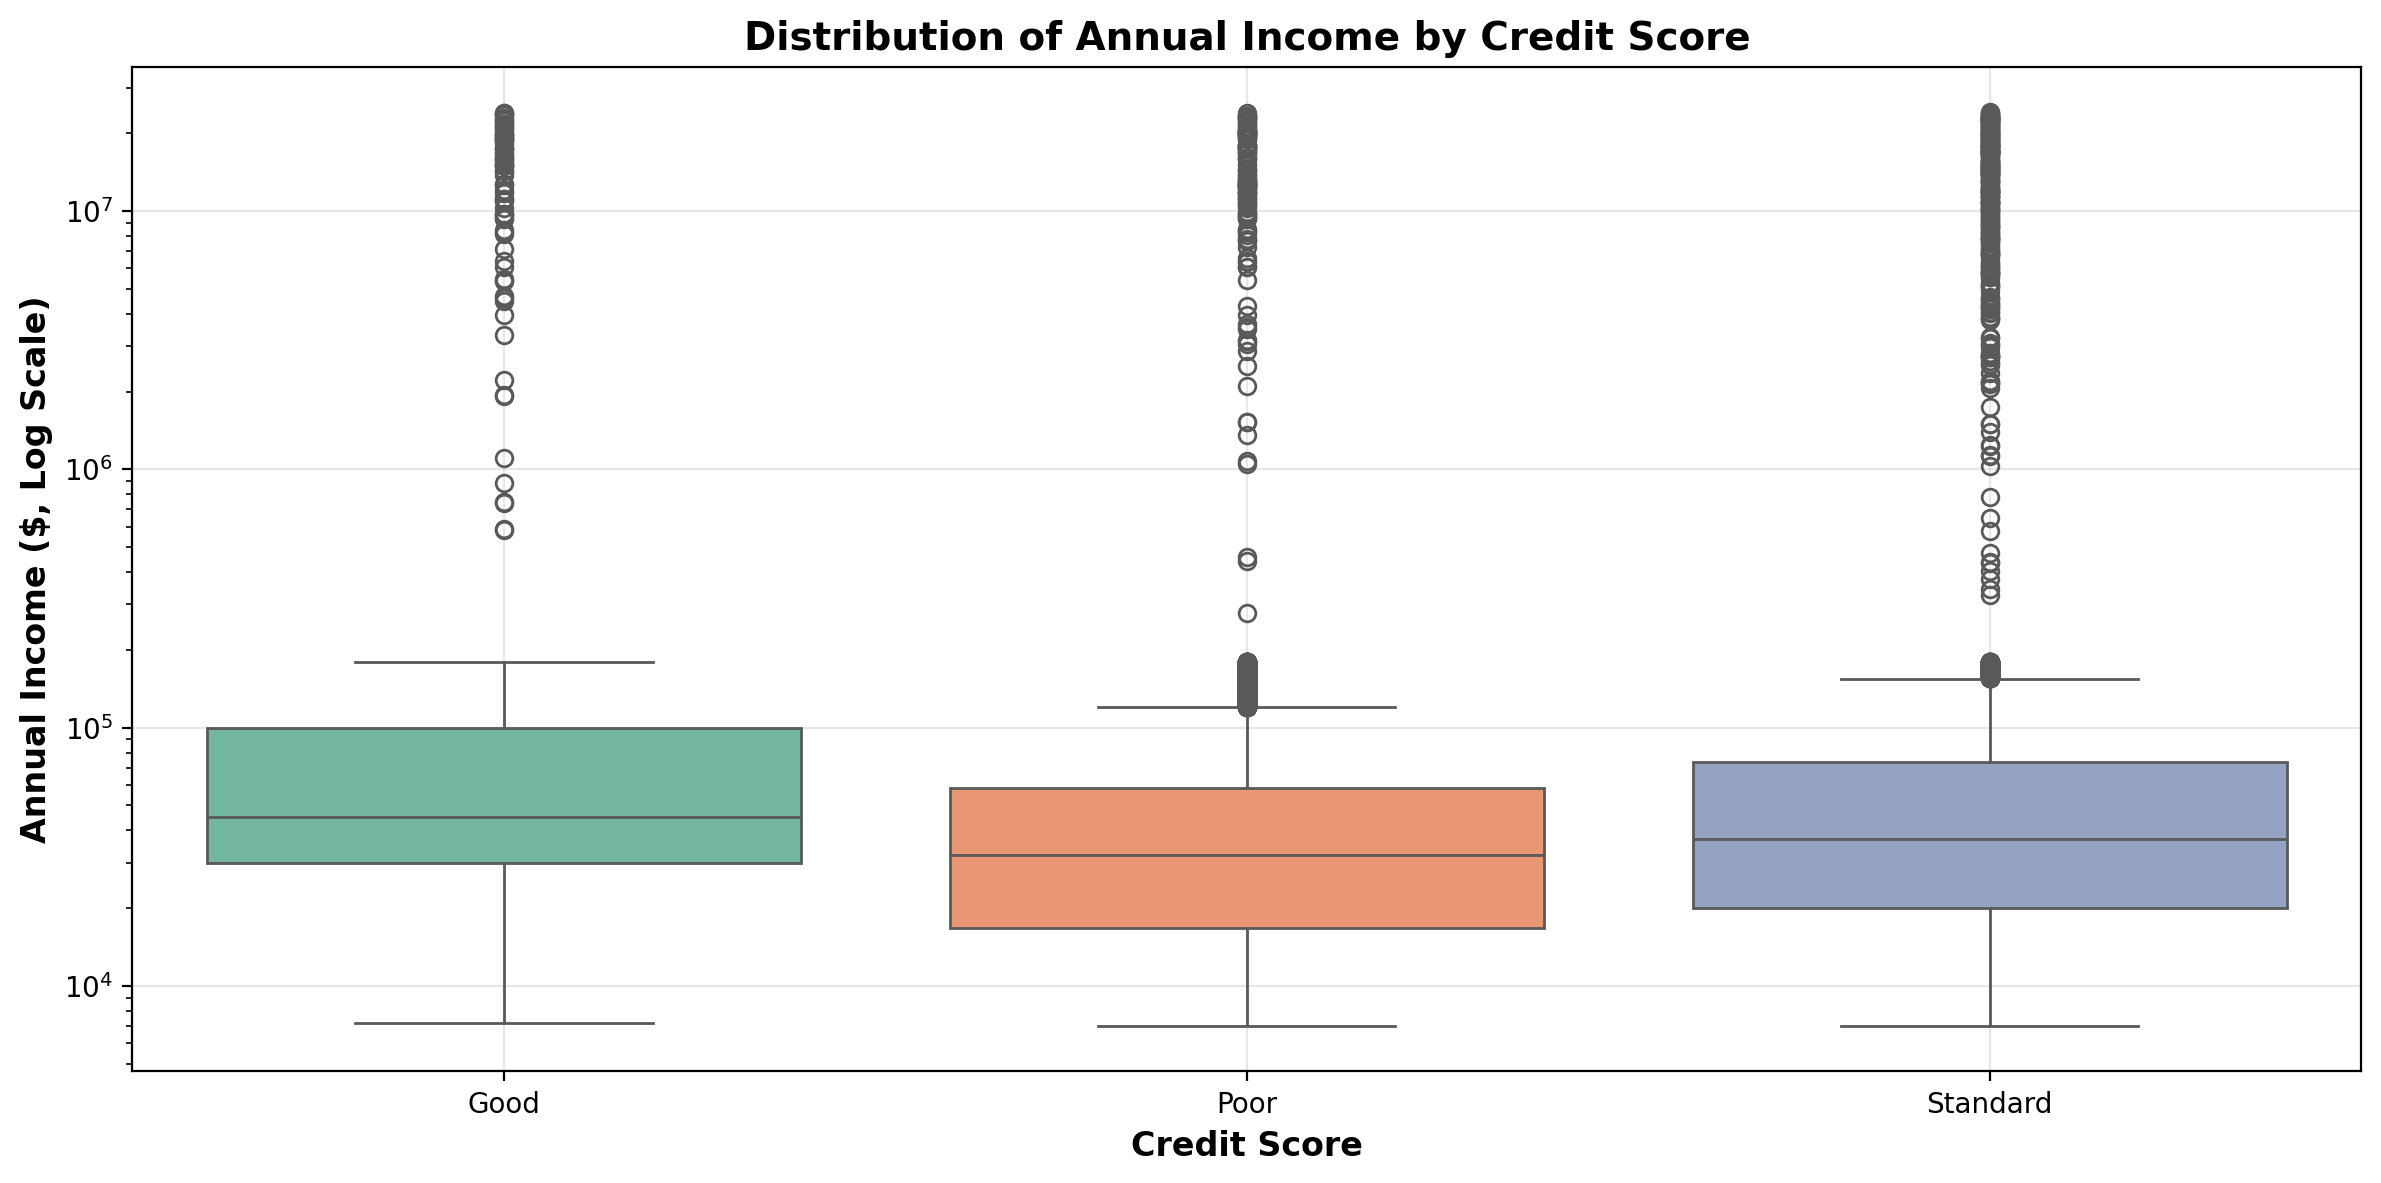

In [54]:
plt.figure(figsize=(12, 6))
df_plot = df[df['Annual_Income'].notna() & (df['Annual_Income'] > 0)]

sns.boxplot(x='Credit_Score', y='Annual_Income', data=df_plot, 
            hue='Credit_Score', palette='Set2', legend=False)

plt.xlabel('Credit Score', fontsize=12, fontweight='bold')
plt.ylabel('Annual Income ($, Log Scale)', fontsize=12, fontweight='bold')
plt.title('Distribution of Annual Income by Credit Score', 
          fontsize=14, fontweight='bold')


plt.yscale('log')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [55]:
# : Number of Bank Accounts

In [56]:
df['Num_Bank_Accounts'].describe()

count    50000.000000
mean        16.648400
std        115.230411
min         -1.000000
25%          3.000000
50%          6.000000
75%          7.000000
max       1798.000000
Name: Num_Bank_Accounts, dtype: float64

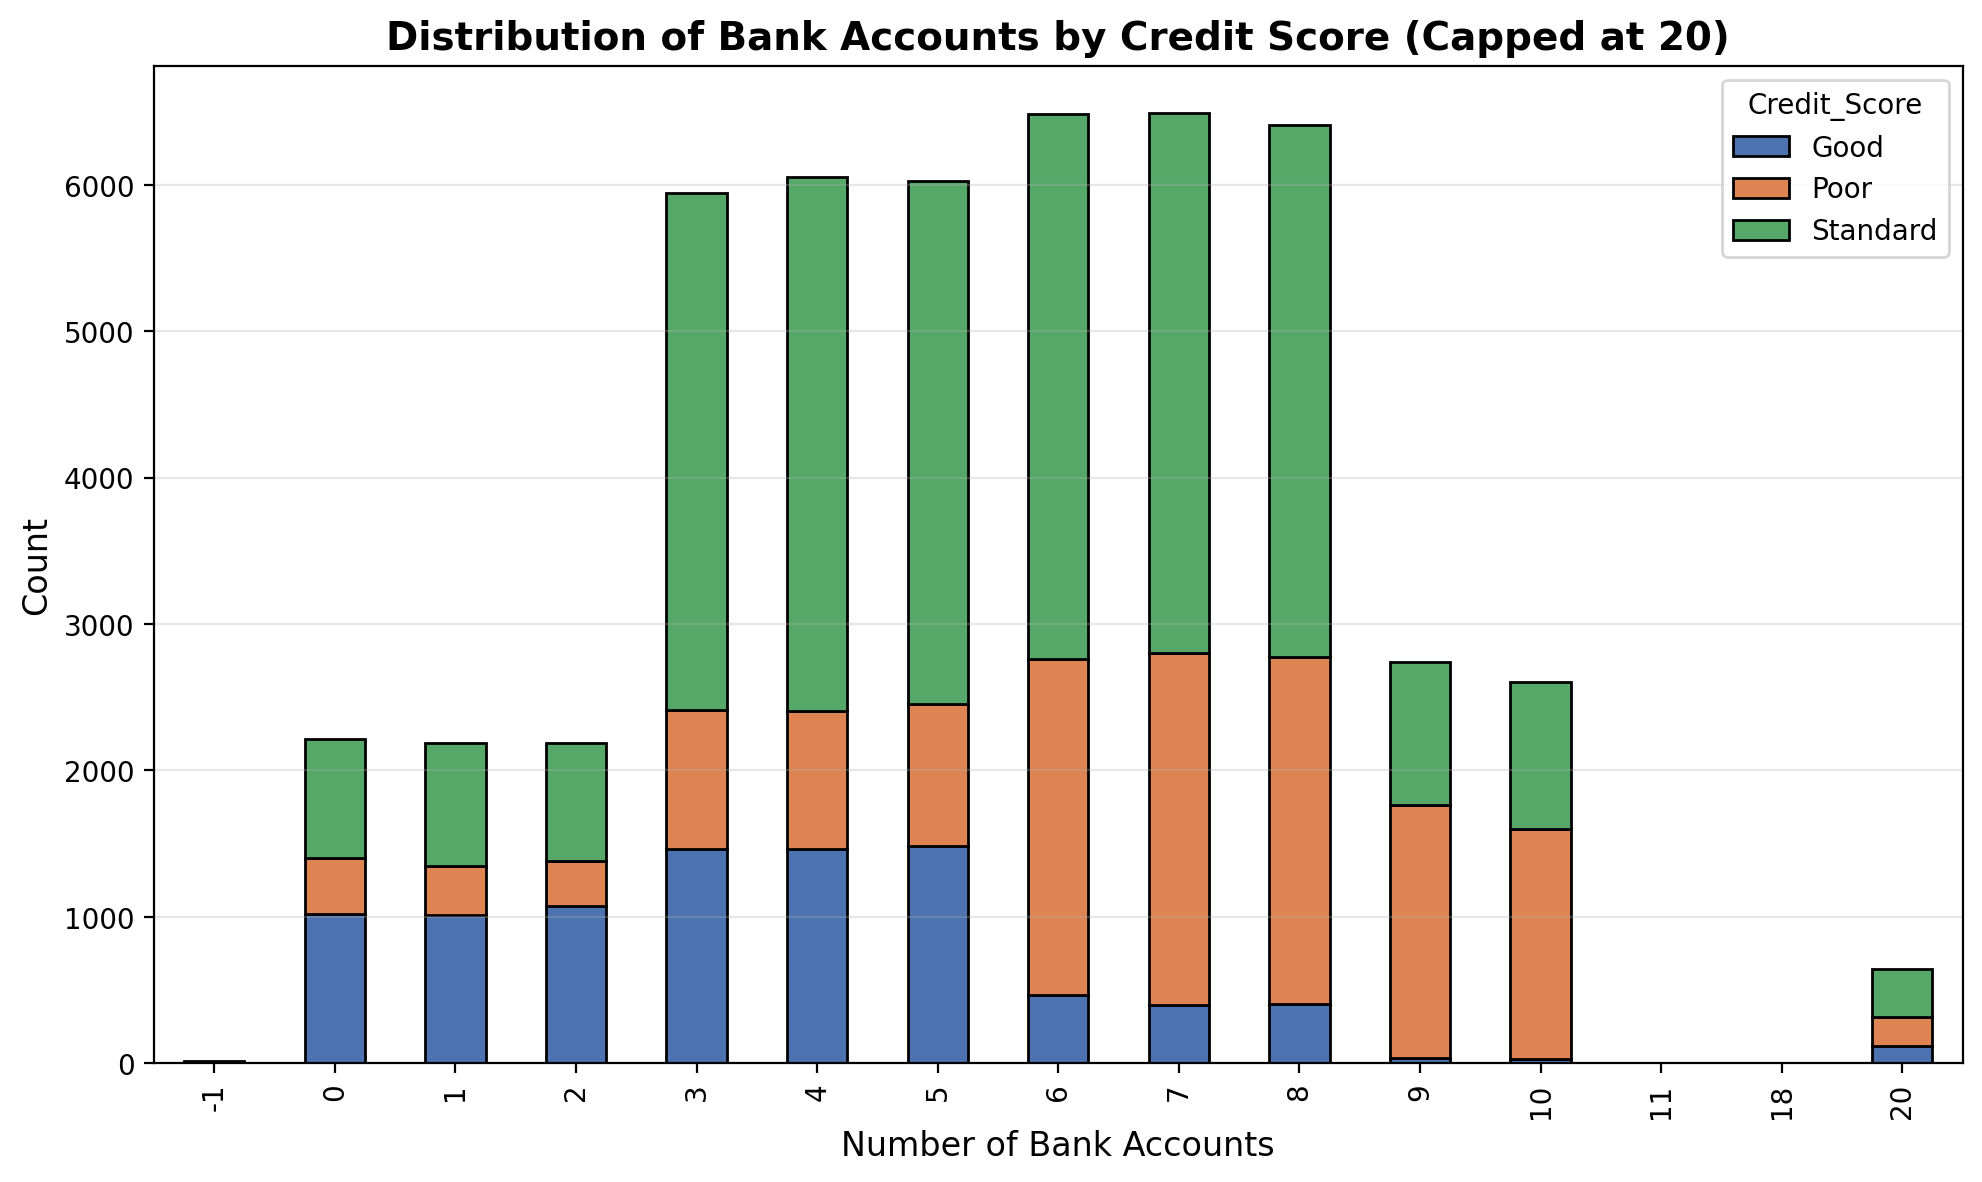

In [57]:
bank_credit = pd.crosstab(df['Num_Bank_Accounts'].clip(upper=20), df['Credit_Score'])
bank_credit.plot(kind='bar', stacked=True, figsize=(10,6),
                 color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')

plt.title('Distribution of Bank Accounts by Credit Score (Capped at 20)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Bank Accounts', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

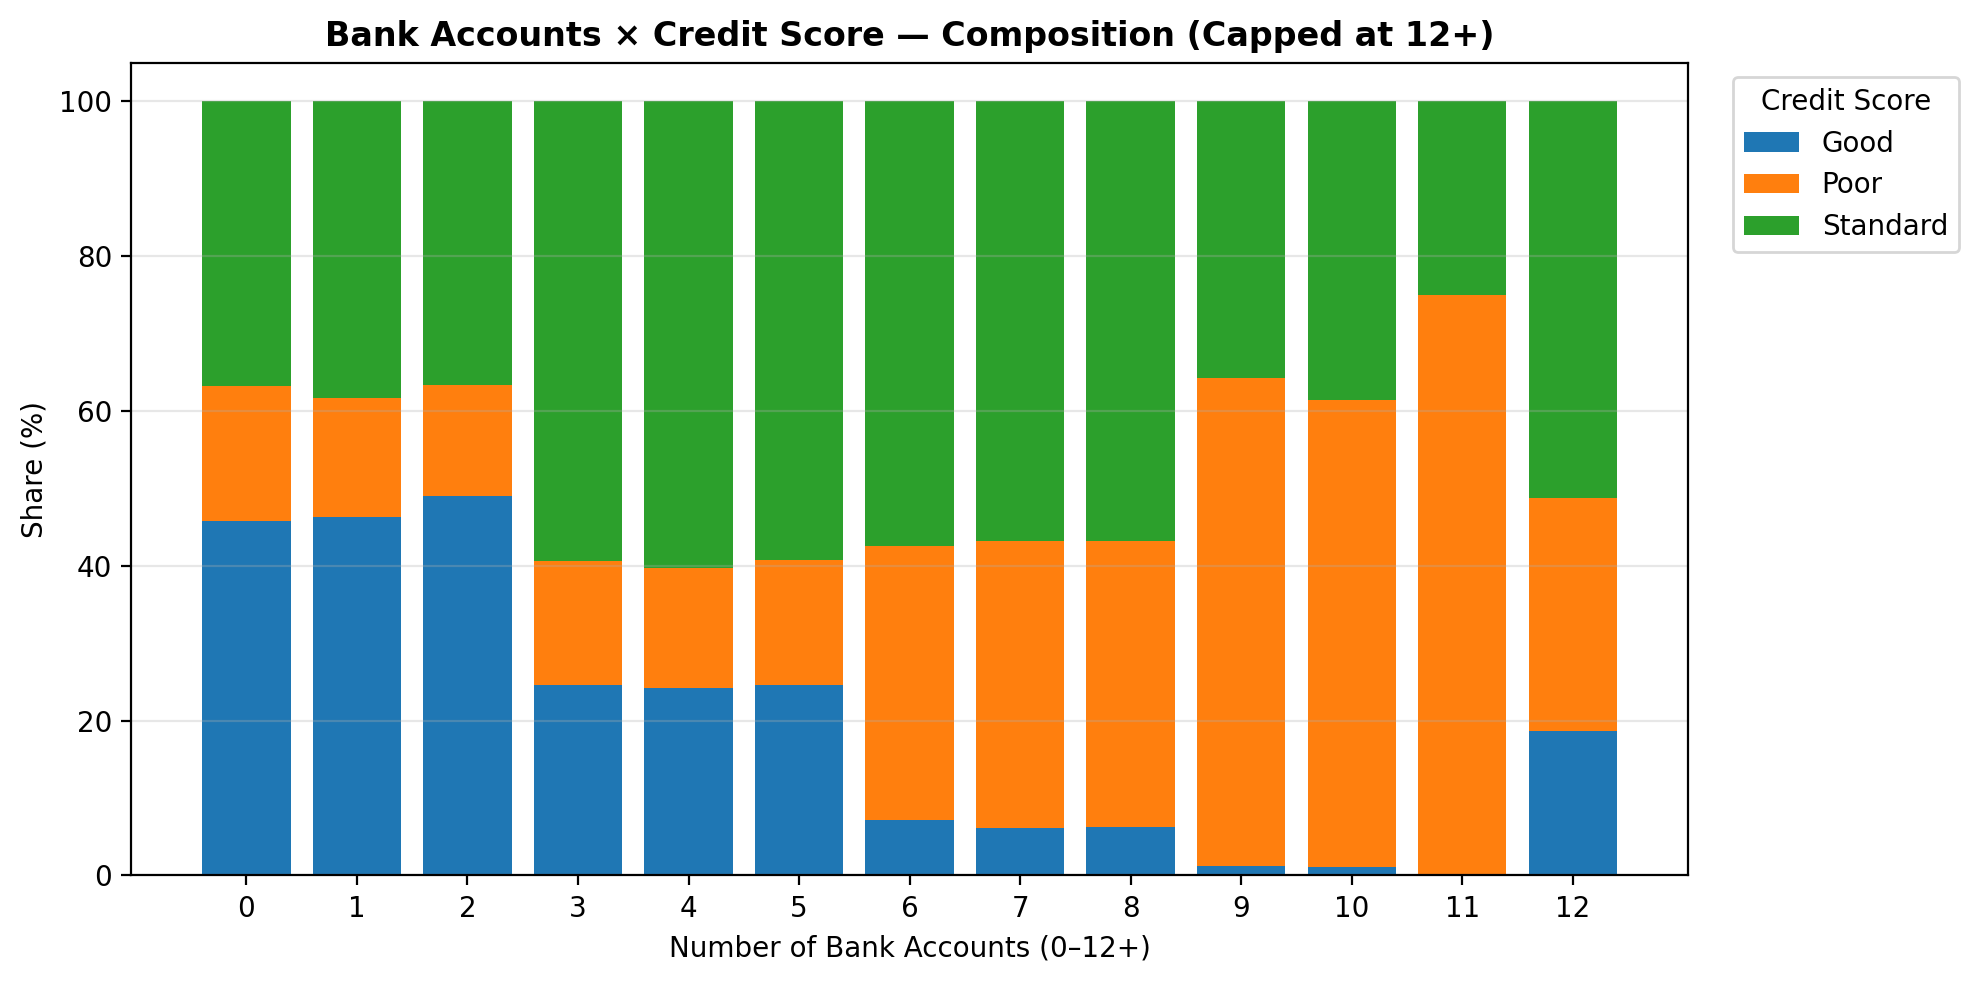

In [58]:
# Preprocessing: Merge the long tail; Remove outliers (such as -1)
s = df['Num_Bank_Accounts'].clip(lower=0, upper=12).astype(int)
s = s.where(s <= 11, other=12)  # 12 represents 12+

ct = pd.crosstab(s, df['Credit_Score']).sort_index()
pct = ct.div(ct.sum(axis=1), axis=0) * 100  # rows normalized to percentages

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(pct))
for col in pct.columns:          
    ax.bar(pct.index.astype(str), pct[col].values, bottom=bottom, label=col)
    bottom += pct[col].values

ax.set_title('Bank Accounts × Credit Score — Composition (Capped at 12+)', fontweight='bold')
ax.set_xlabel('Number of Bank Accounts (0–12+)')
ax.set_ylabel('Share (%)')
ax.legend(title='Credit Score', bbox_to_anchor=(1.02,1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Credit Mix vs. Credit Score (Stacked Bar Chart)

Analyze the relationship between different types of credit combinations and credit scores.

<Figure size 1200x600 with 0 Axes>

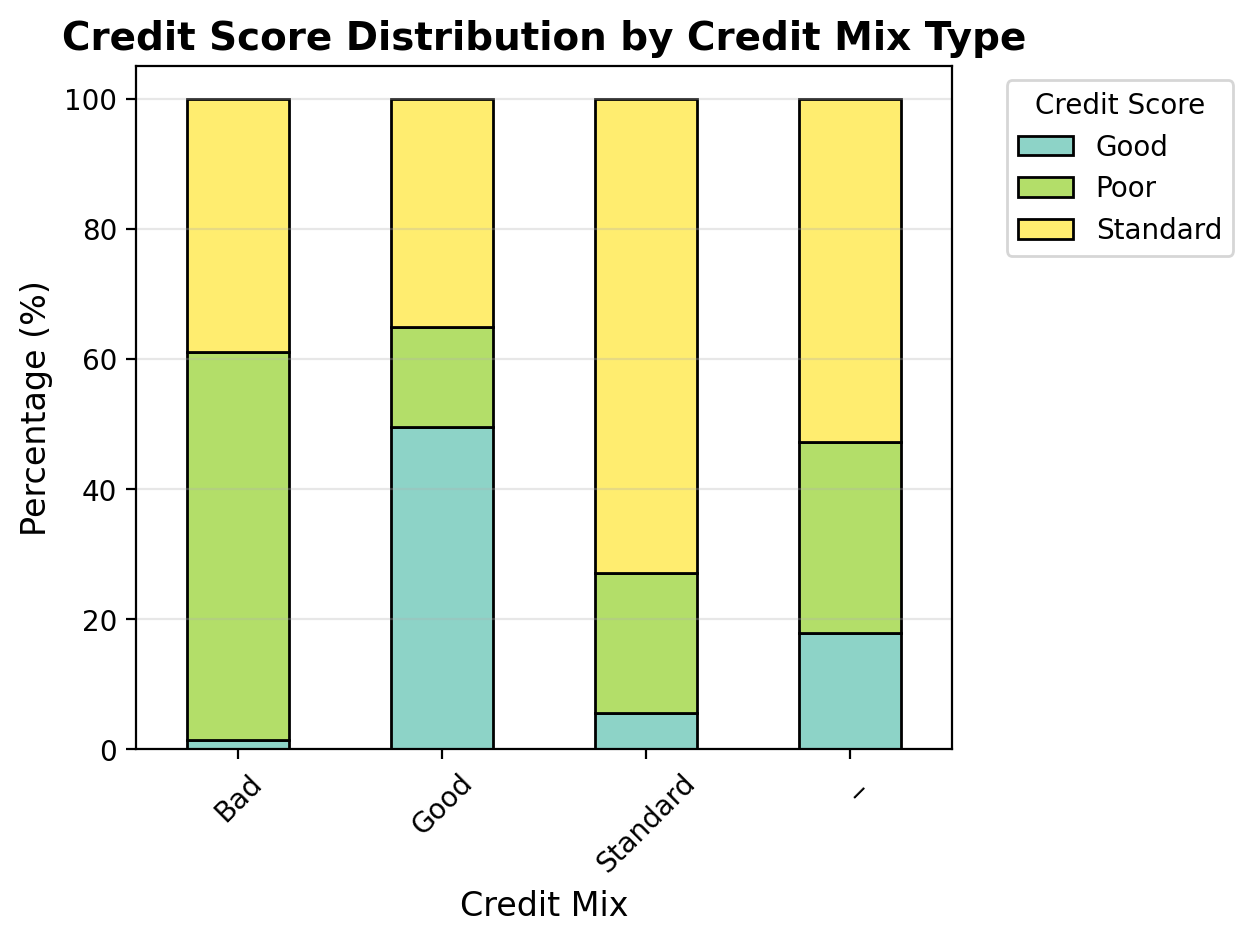

In [59]:
plt.figure(figsize=(12, 6))
credit_mix_data = pd.crosstab(df['Credit_Mix'], df['Credit_Score'], normalize='index') * 100
credit_mix_data.plot(kind='bar', stacked=True, colormap='Set3', edgecolor='black')
plt.xlabel('Credit Mix', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Credit Score Distribution by Credit Mix Type', fontsize=14, fontweight='bold')
plt.legend(title='Credit Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Payment Behavior vs. Credit Score (Heatmap)
Display the relationship between payment behavior and credit score through a heatmap.


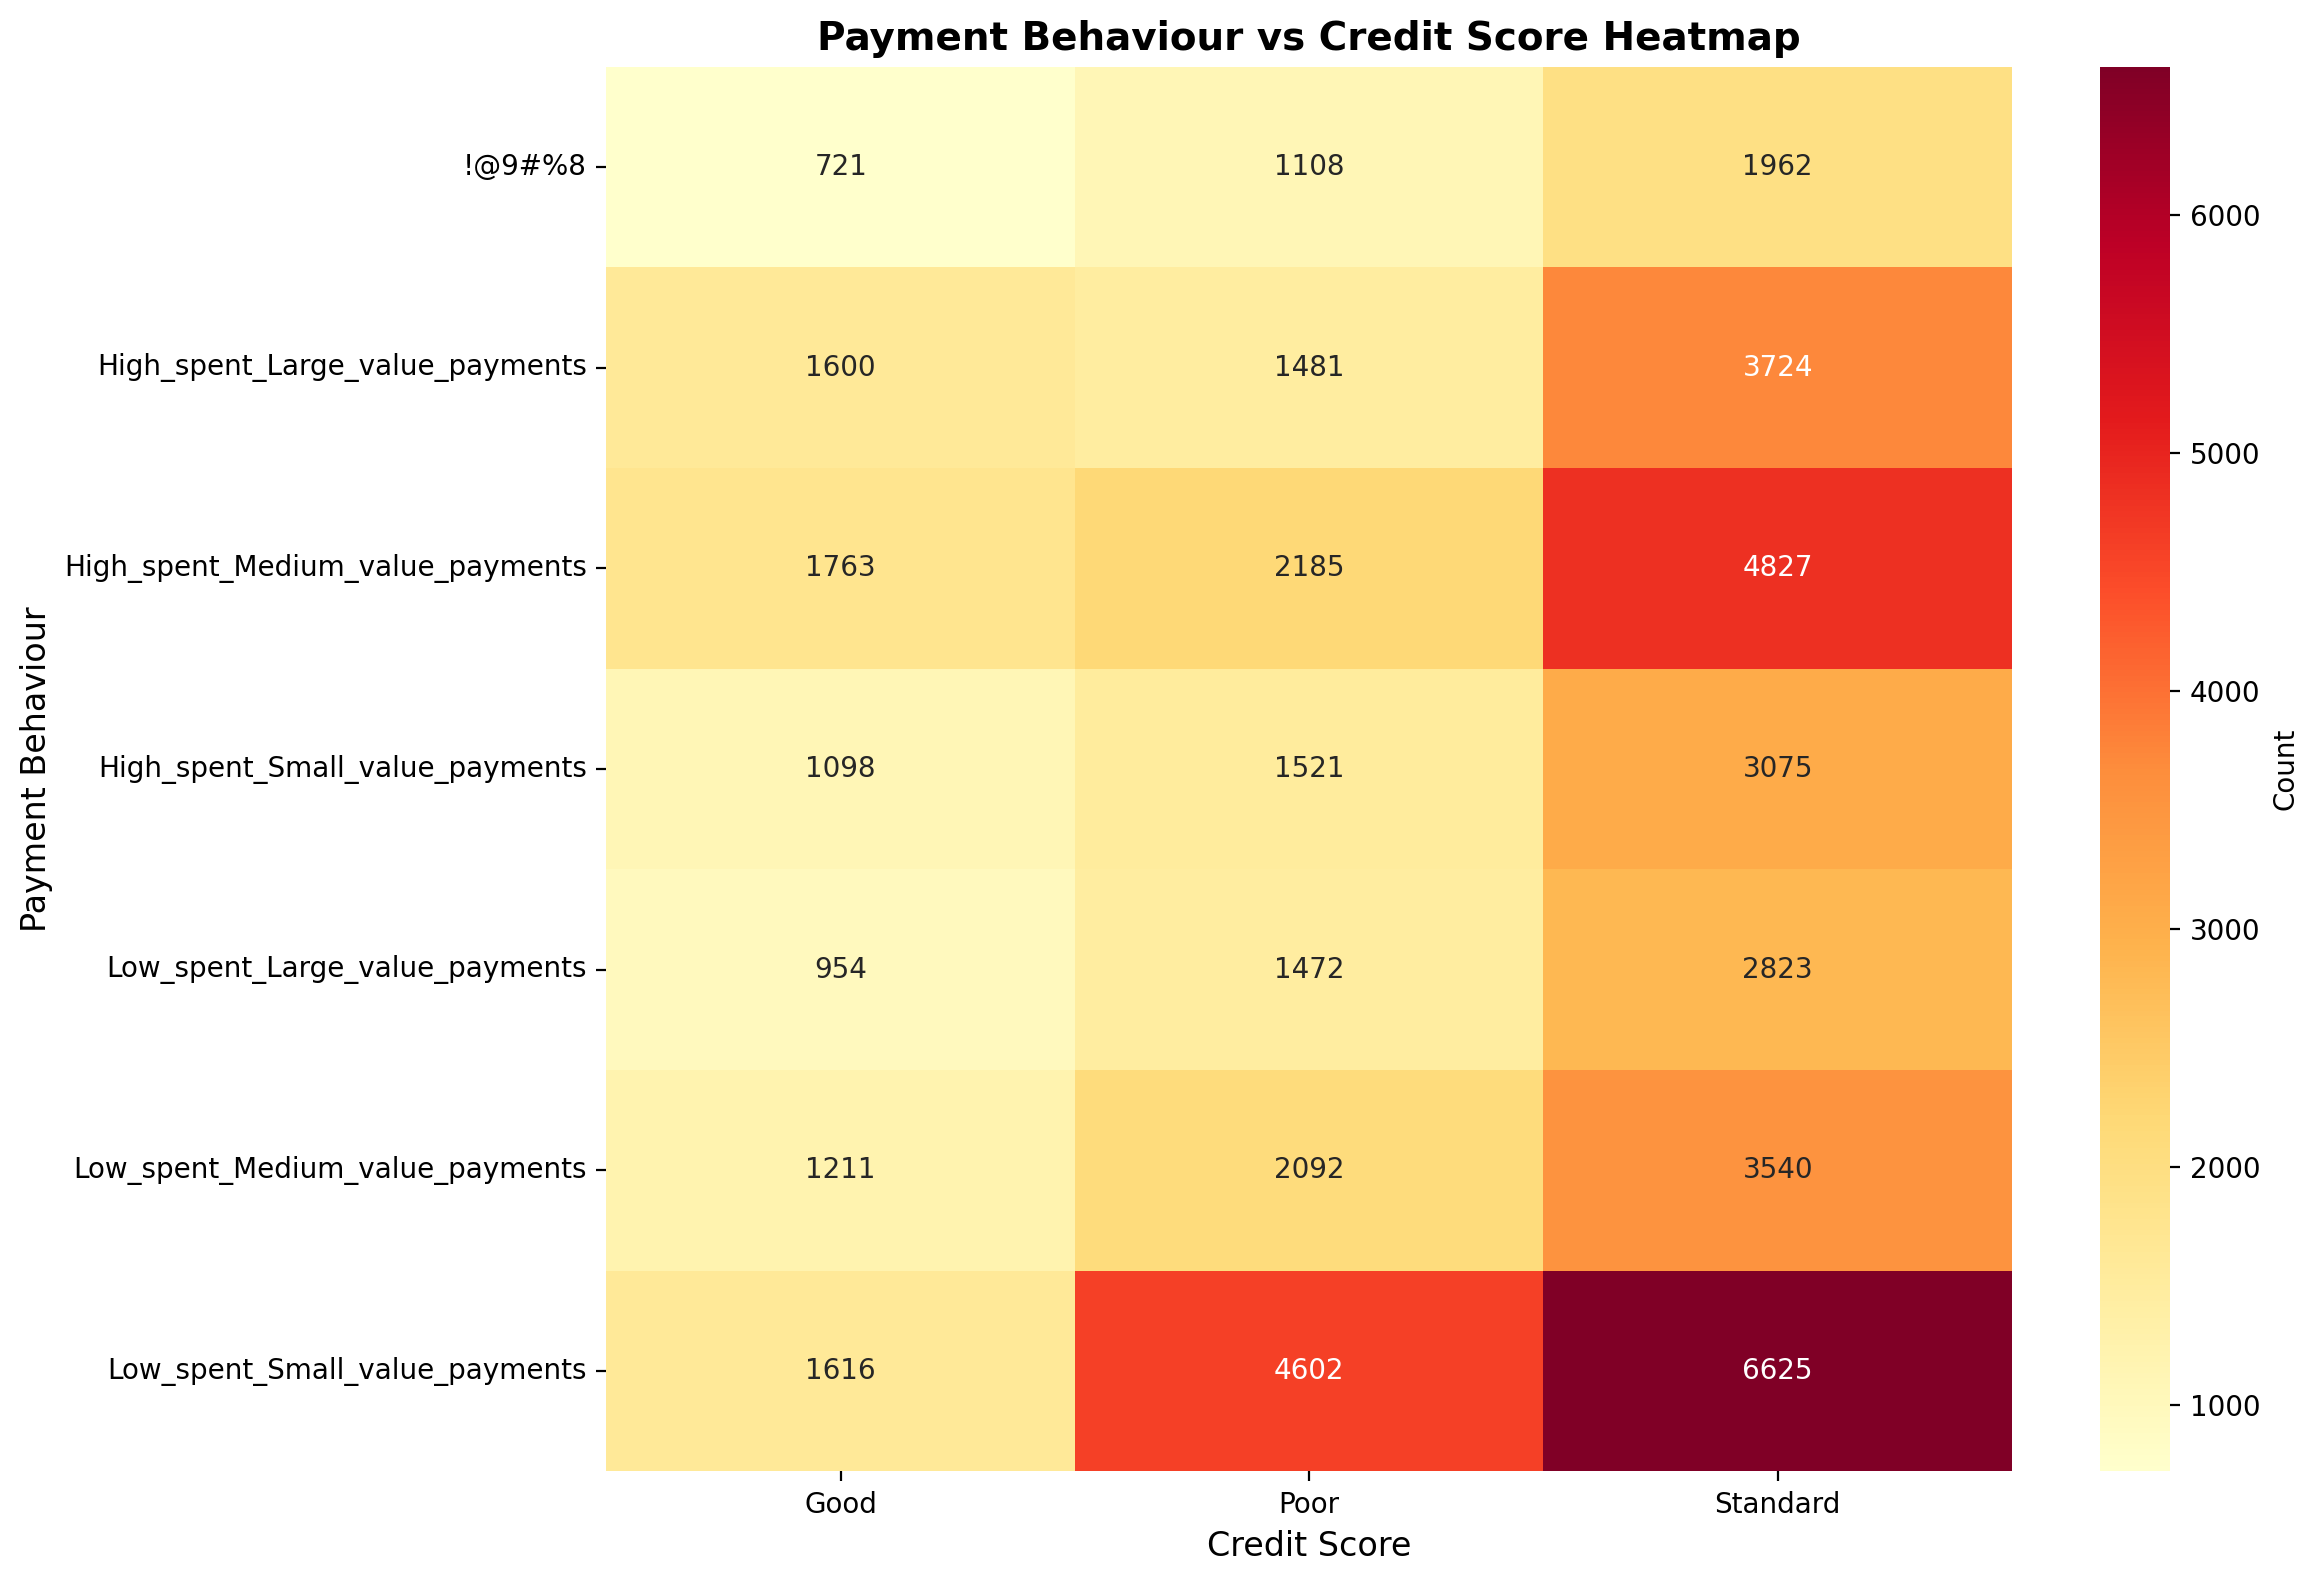

In [60]:
plt.figure(figsize=(12, 8))
payment_behavior_crosstab = pd.crosstab(df['Payment_Behaviour'], df['Credit_Score'])
sns.heatmap(payment_behavior_crosstab, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Payment Behaviour', fontsize=12)
plt.title('Payment Behaviour vs Credit Score Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Monthly Inhand Salary分布 

Use a KDE plot to show the monthly income distribution across different credit score groups.

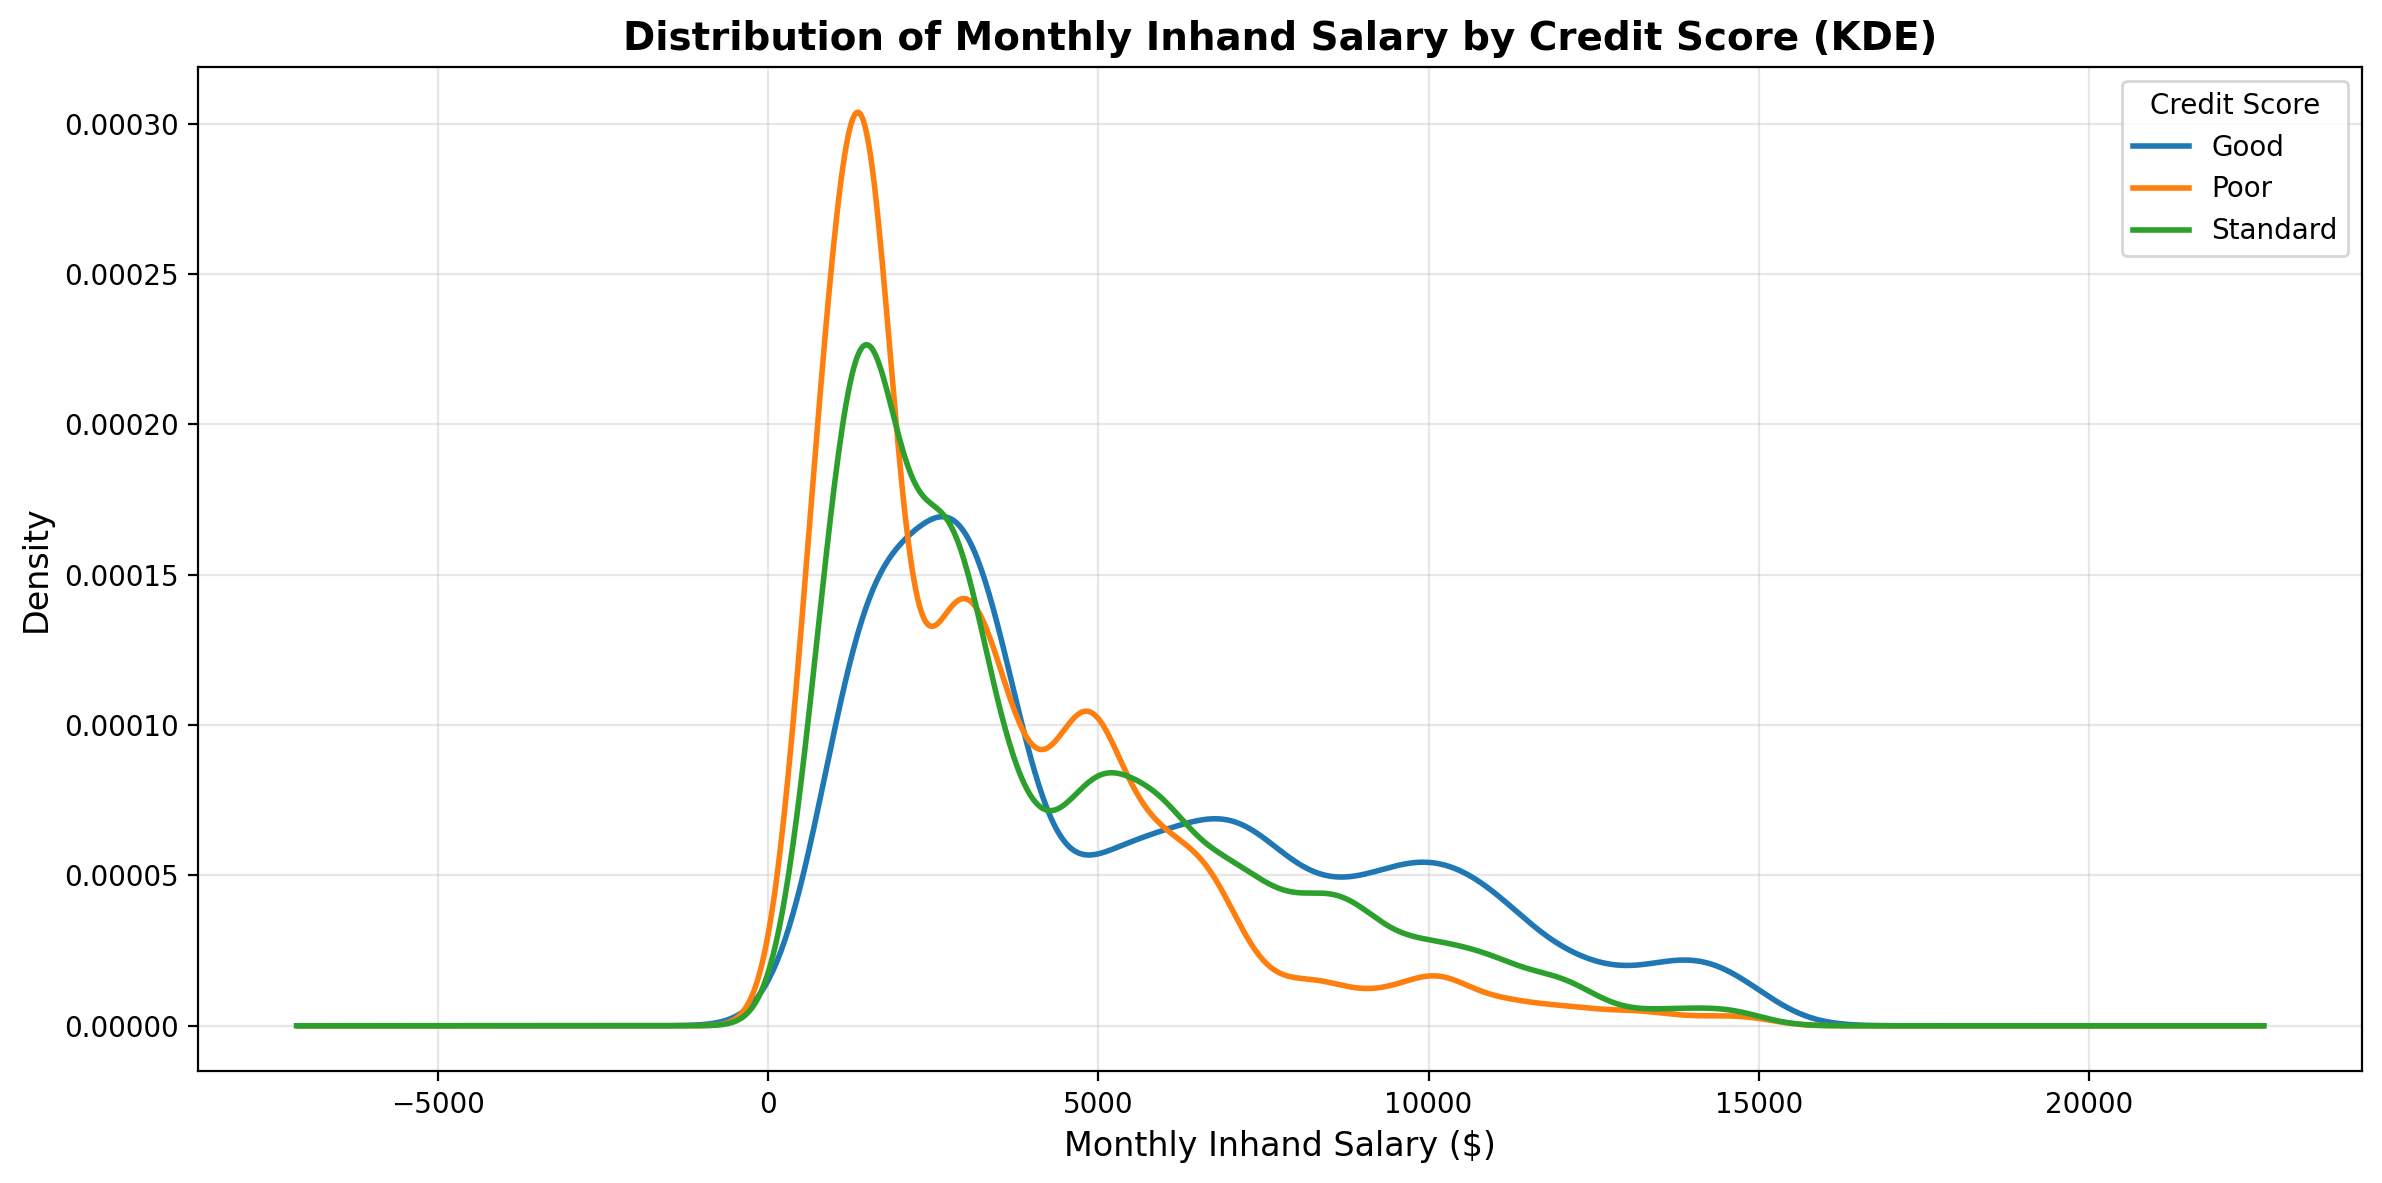

In [61]:
plt.figure(figsize=(12, 6))
df_salary = df[df['Monthly_Inhand_Salary'].notna() & 
               (df['Monthly_Inhand_Salary'] > 0) & 
               (df['Monthly_Inhand_Salary'] < 20000)]

for score in df['Credit_Score'].unique():
    if pd.notna(score):
        data = df_salary[df_salary['Credit_Score'] == score]['Monthly_Inhand_Salary']
        if len(data) > 0:
            data.plot(kind='kde', label=f'{score}', linewidth=2)

plt.xlabel('Monthly Inhand Salary ($)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Distribution of Monthly Inhand Salary by Credit Score (KDE)', fontsize=14, fontweight='bold')
plt.legend(title='Credit Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Outstanding Debt vs Credit Utilization 
Explore the relationship between outstanding debt and credit utilization ratio, categorized by credit score.


In [62]:
df['Outstanding_Debt'] = pd.to_numeric(df['Outstanding_Debt'], errors='coerce')

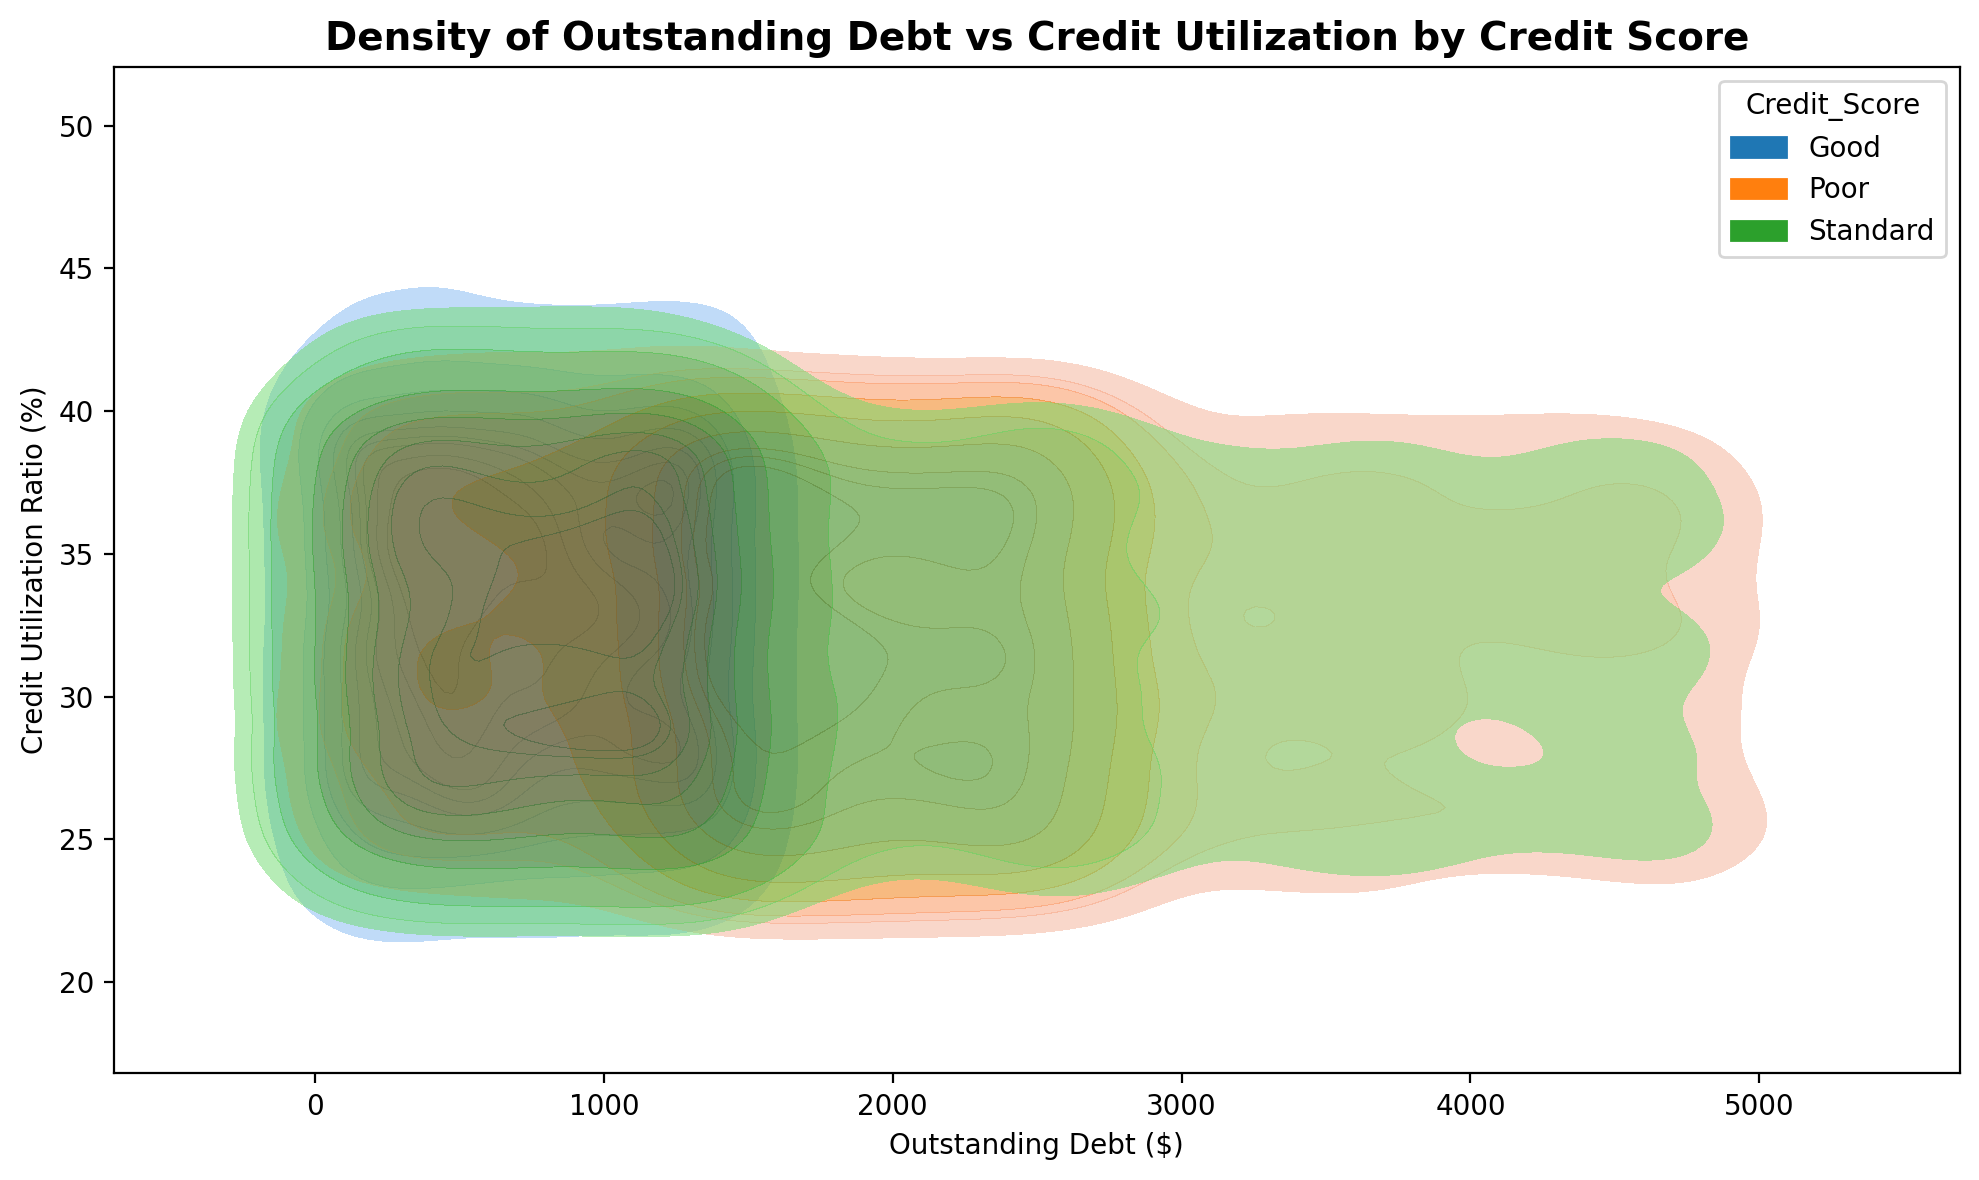

In [63]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df, x='Outstanding_Debt', y='Credit_Utilization_Ratio',
    hue='Credit_Score', fill=True, thresh=0.05, alpha=0.5, common_norm=False
)
plt.title('Density of Outstanding Debt vs Credit Utilization by Credit Score', fontsize=14, fontweight='bold')
plt.xlabel('Outstanding Debt ($)')
plt.ylabel('Credit Utilization Ratio (%)')
plt.tight_layout()
plt.show()

## Number of Loans vs Credit Score 


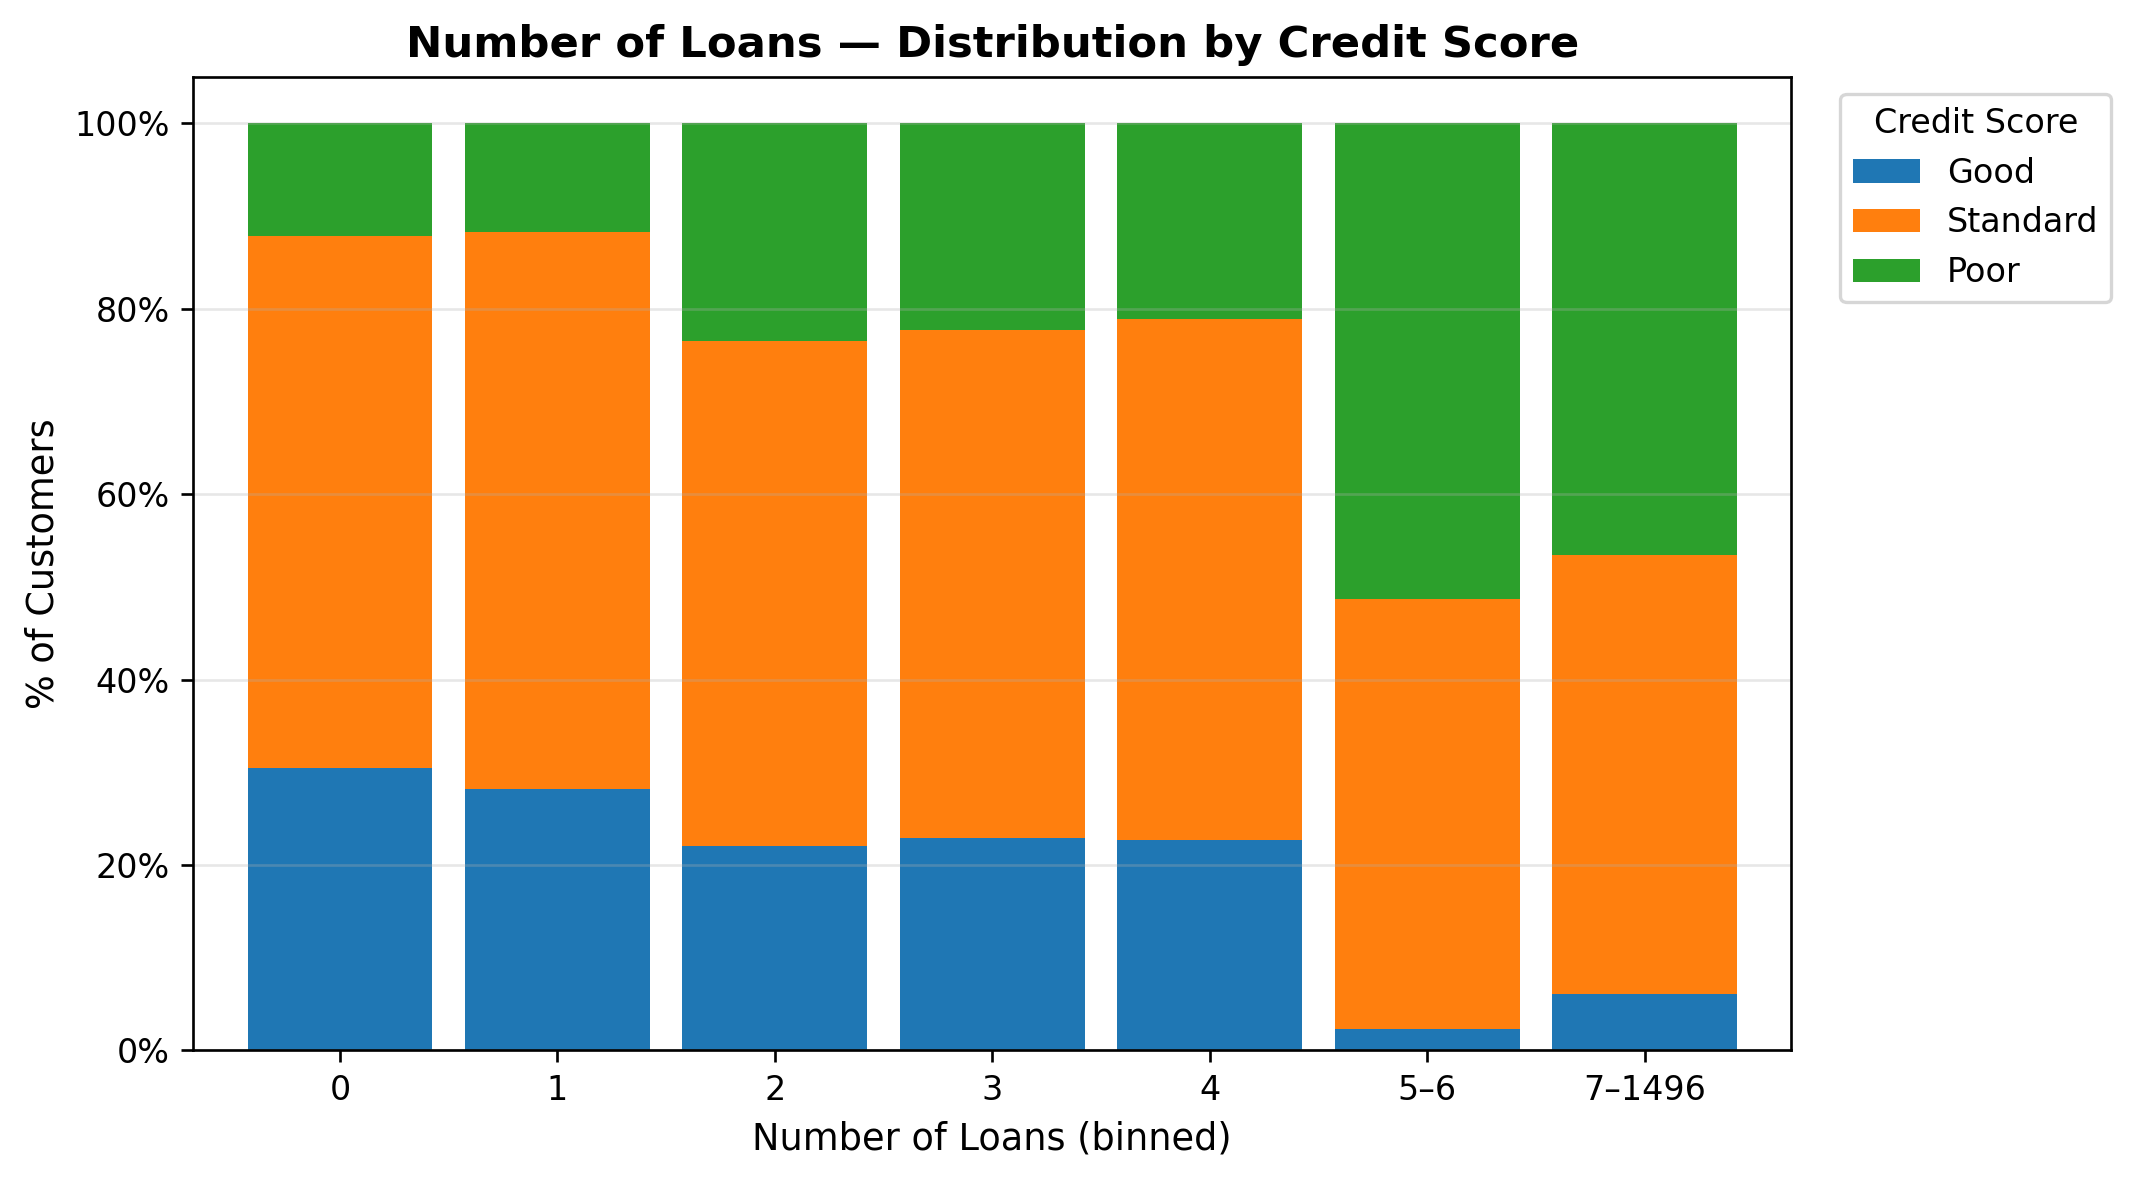

In [64]:
import matplotlib.ticker as mtick

df_loans = df.copy()

col = 'Num_of_Loan'
df_loans[col] = (
    df_loans[col]
    .astype(str).str.strip()
    .str.replace(r'[^0-9\.]', '', regex=True)  # e.g., '5+' -> '5'
    .replace({'': np.nan})
    .pipe(pd.to_numeric, errors='coerce')
)

# 2) Drop missing values and apply reasonable constraints 
# (non-negative, round to nearest integer)
df_loans = df_loans[df_loans[col].notna()].copy()
df_loans[col] = df_loans[col].clip(lower=0).round().astype(int)

# 3) Bin the number of loans dynamically based on the upper bound 
# (to prevent out-of-range issues)
hi = int(df_loans[col].max())
bins   = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 6.5, hi + 0.5]
labels = ['0','1','2','3','4','5–6', f'7–{hi}']
df_loans['loan_bin'] = pd.cut(df_loans[col], bins=bins, labels=labels, include_lowest=True)

# 4) Sort credit score levels (optional)
order_cs = ['Good','Standard','Poor']
df_loans = df_loans[df_loans['Credit_Score'].isin(order_cs)].copy()
df_loans['Credit_Score'] = pd.Categorical(df_loans['Credit_Score'], order_cs, ordered=True)

# 5) Create crosstab → percentage stacked bar chart
ct  = pd.crosstab(df_loans['loan_bin'], df_loans['Credit_Score'])
pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9,5), dpi=120)
pct.plot(kind='bar', stacked=True, ax=ax, width=0.85)

ax.set_title('Number of Loans — Distribution by Credit Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Loans (binned)', fontsize=11)
ax.set_ylabel('% of Customers', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Credit Score', bbox_to_anchor=(1.02,1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



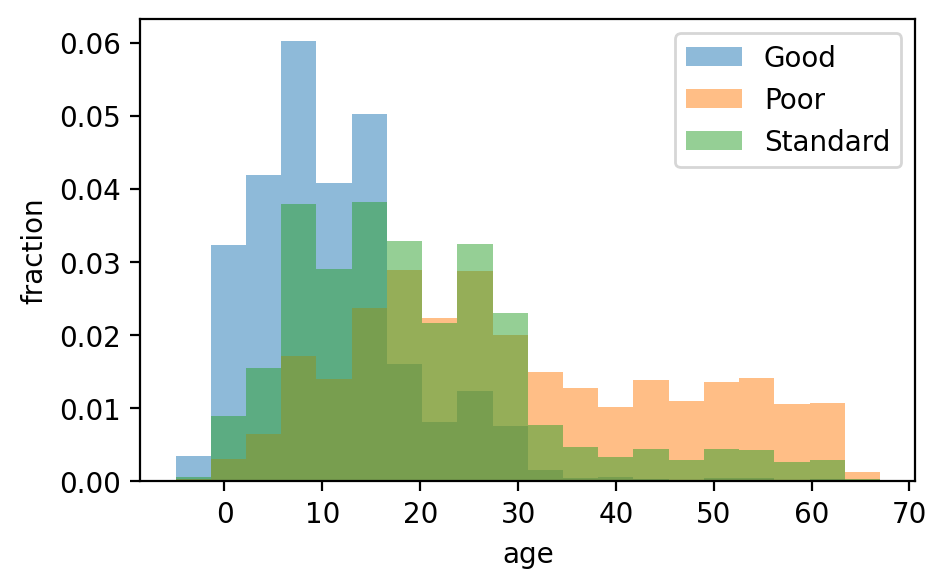

In [65]:
categories = df['Credit_Score'].unique()
bin_range = (df['Delay_from_due_date'].min(),df['Delay_from_due_date'].max())

plt.figure(figsize=(5,3))

for c in categories:
    plt.hist(df[df['Credit_Score']==c]['Delay_from_due_date'],alpha=0.5,label=c,range=bin_range,bins=20,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('age')
plt.show()

In [66]:
# The correlation between occupation and credit score

In [67]:
df.Occupation.value_counts()

Occupation
_______          3499
Lawyer           3255
Engineer         3244
Accountant       3180
Teacher          3178
Scientist        3168
Architect        3162
Mechanic         3140
Media_Manager    3115
Developer        3114
Entrepreneur     3055
Doctor           3052
Writer           2997
Manager          2963
Journalist       2958
Musician         2920
Name: count, dtype: int64

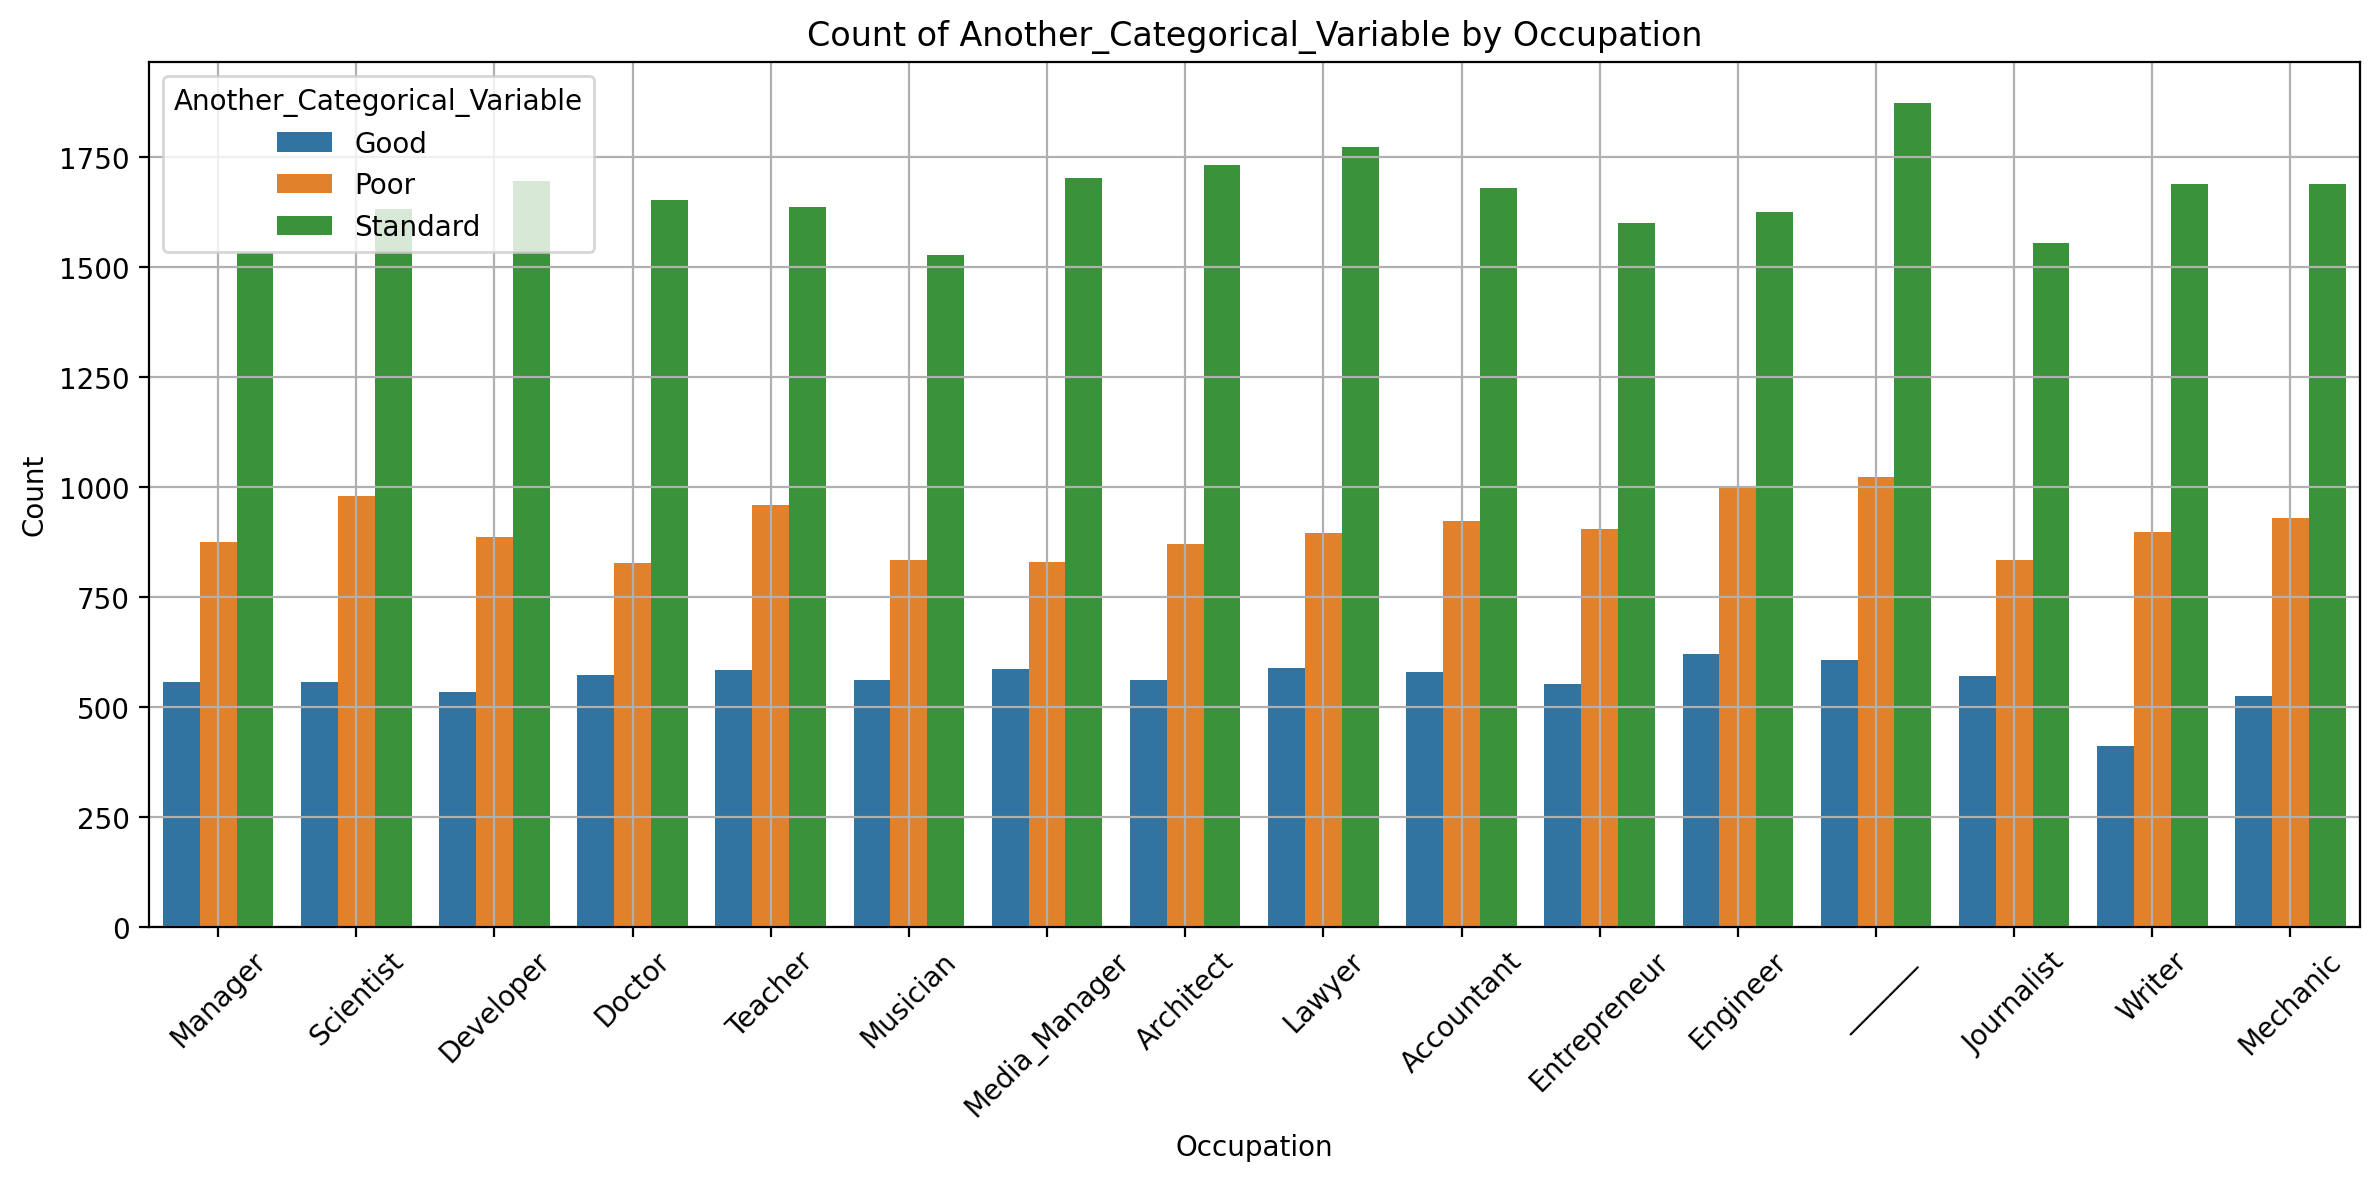

In [68]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Occupation', hue='Credit_Score', data=df)
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.title('Count of Another_Categorical_Variable by Occupation')
plt.xticks(rotation=45)
plt.legend(title='Another_Categorical_Variable')
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
# The distribution gap of credit scores among different occupations is indeed not significant


## Correlation Matrix of Numerical Features 

Display the correlation matrix among all numerical features.

In [70]:
credit_score_counts = df['Credit_Score'].value_counts().sort_index()

print("\nCredit Score Distribution:")
print("-" * 70)
for category, count in credit_score_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{category:15s}: {count:6d} samples ({percentage:5.2f}%)")

print(f"\nTotal samples: {len(df)}")


Credit Score Distribution:
----------------------------------------------------------------------
Good           :   8963 samples (17.93%)
Poor           :  14461 samples (28.92%)
Standard       :  26576 samples (53.15%)

Total samples: 50000


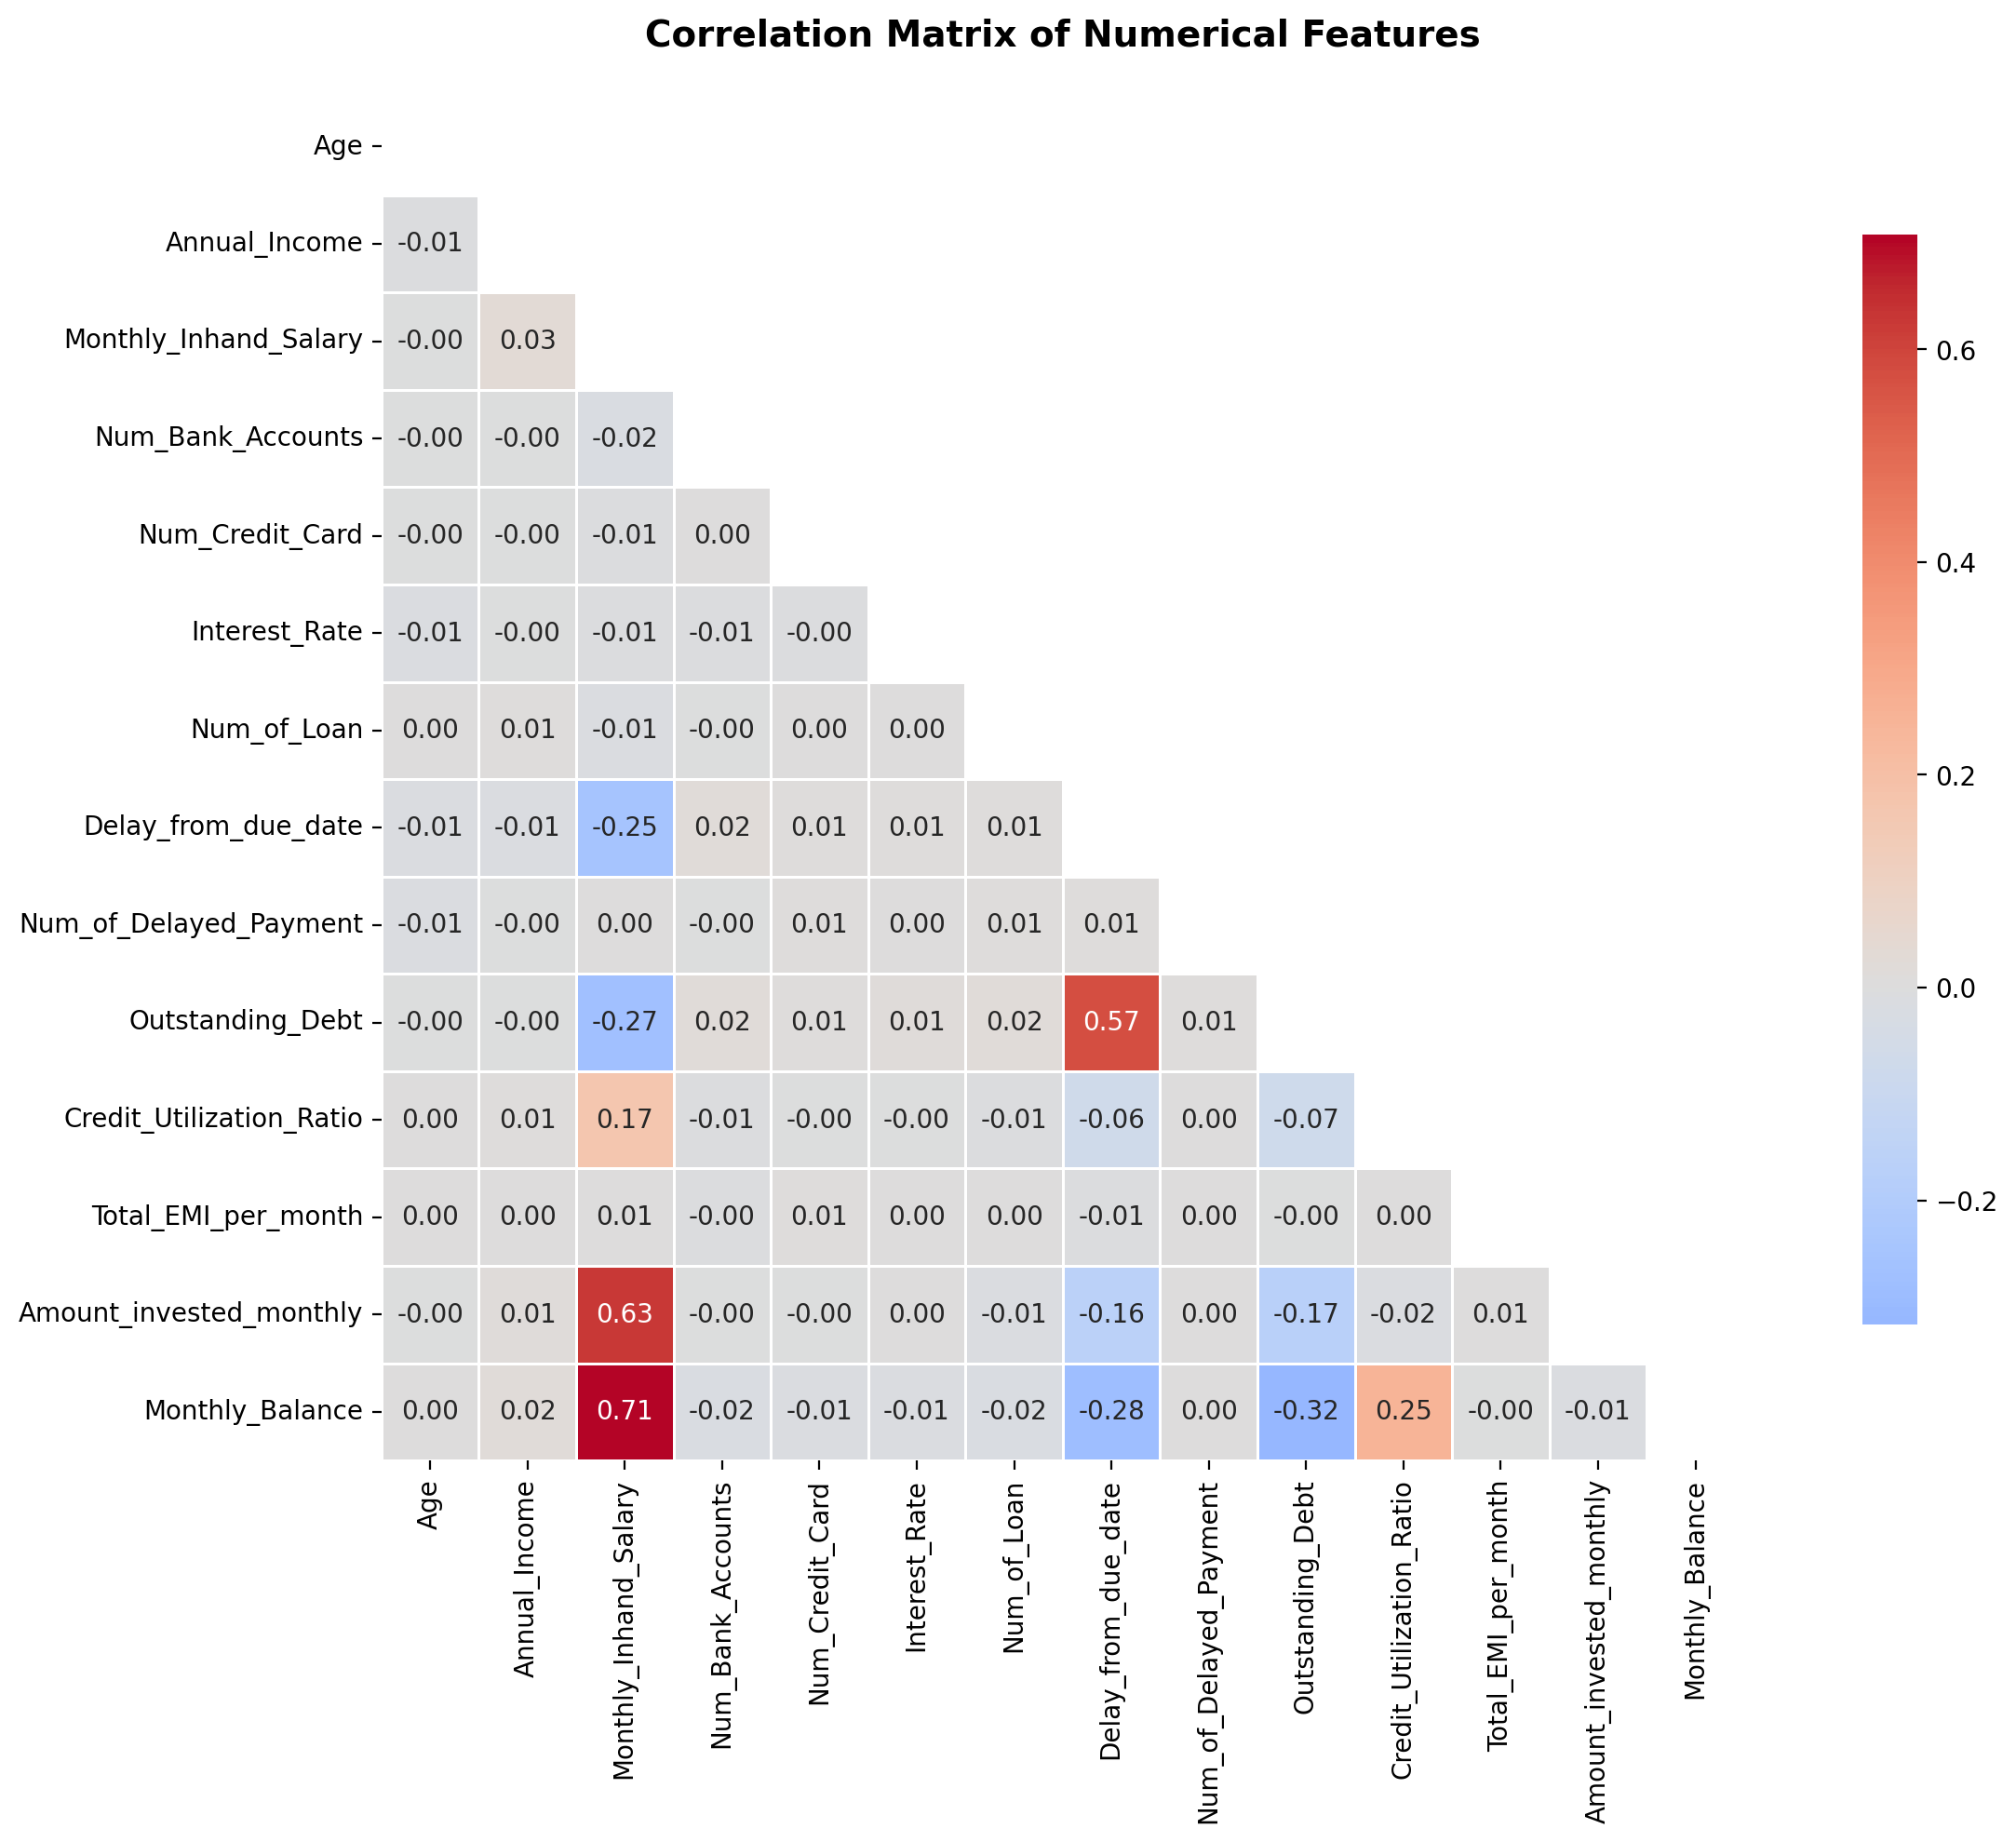

In [71]:
plt.figure(figsize=(14, 10))


numerical_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
                  'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
                  'Num_of_Delayed_Payment', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
                  'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']


existing_cols = [col for col in numerical_cols if col in df.columns]
df_numeric = df[existing_cols].apply(pd.to_numeric, errors='coerce')


corr_matrix = df_numeric.corr()


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

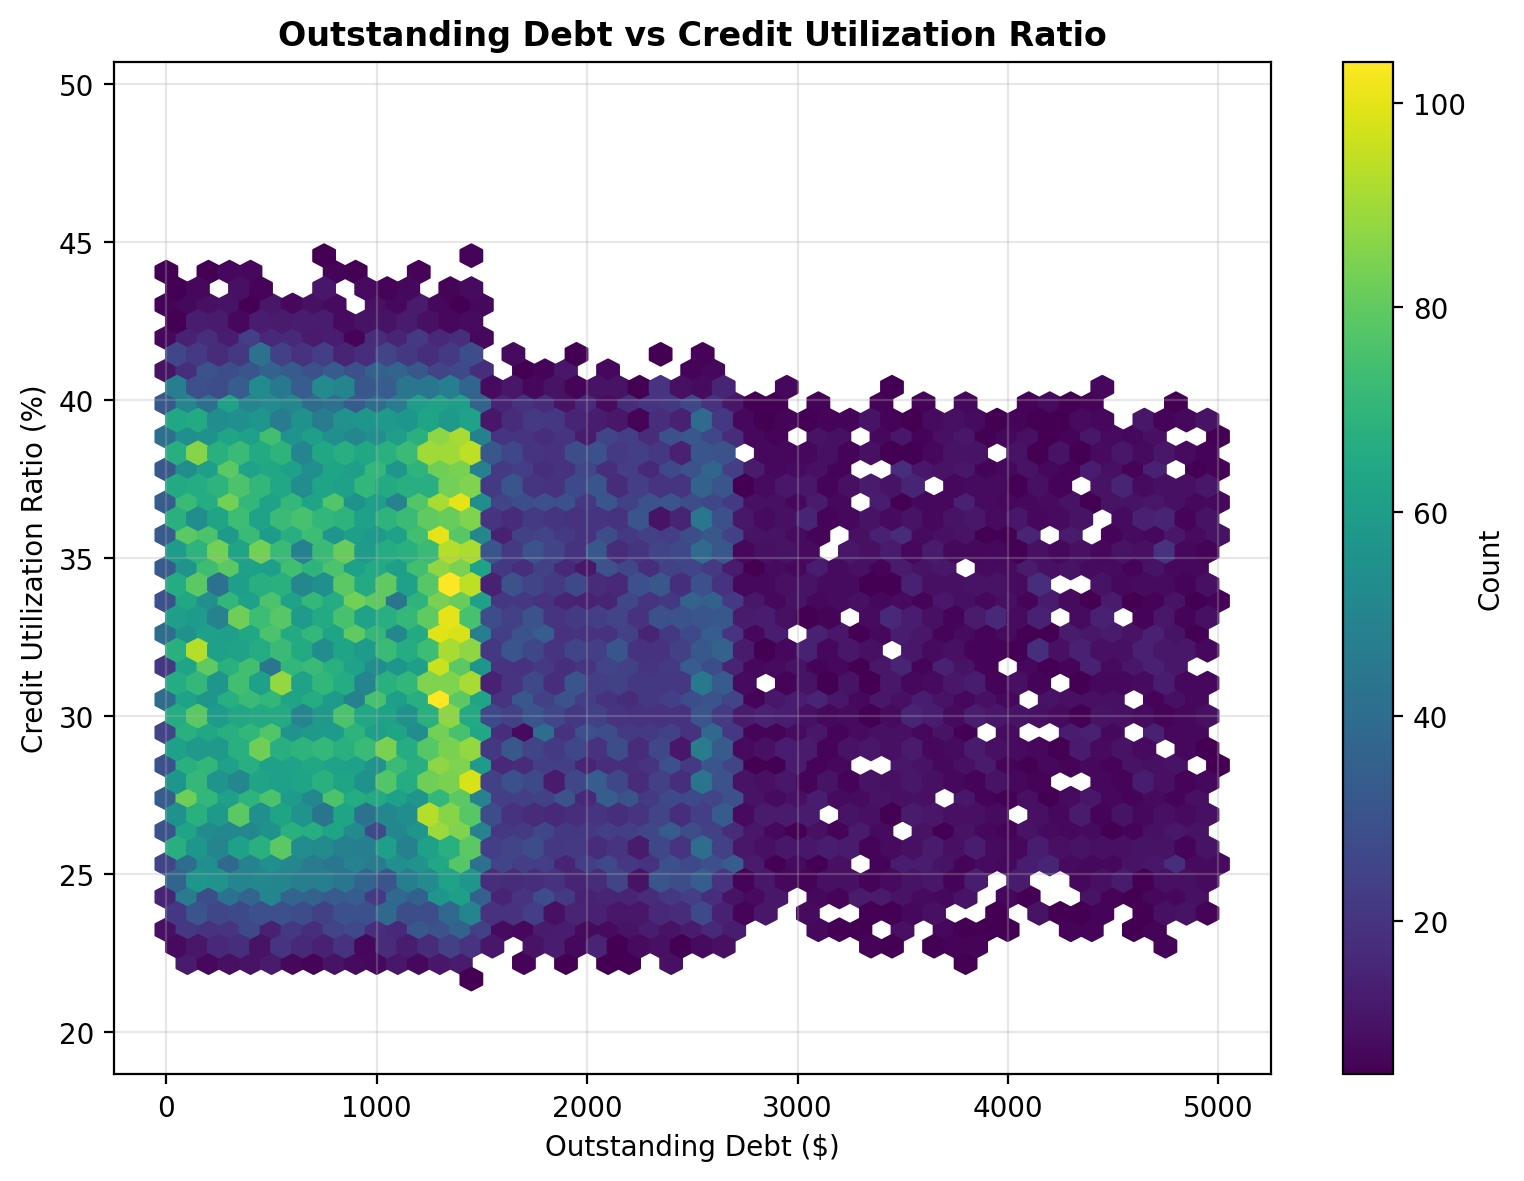

In [72]:
plt.figure(figsize=(8,6))
plt.hexbin(df['Outstanding_Debt'], df['Credit_Utilization_Ratio'],
           gridsize=50, cmap='viridis', mincnt=5)
plt.colorbar(label='Count')
plt.title('Outstanding Debt vs Credit Utilization Ratio', fontweight='bold')
plt.xlabel('Outstanding Debt ($)')
plt.ylabel('Credit Utilization Ratio (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import re


print("="*60)
print("Step 1: Data cleaning and feature transformation")
print("="*60)

# Copy the data to avoid modifying the original df
df_clean = df.copy()

# Convert Age, Annual_Income,Outstanding_Debt, Credit_History_Age
# Num_of_Loan, Num_of_Delayed_Payment, Monthly_Balance,Changed_Credit_Limit to a numeric value
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')


df_clean['Annual_Income'] = pd.to_numeric(df_clean['Annual_Income'], errors='coerce')


df_clean['Outstanding_Debt'] = pd.to_numeric(df_clean['Outstanding_Debt'], errors='coerce')


def parse_credit_history(val):
    if pd.isna(val):
        return np.nan
    years = re.search(r'(\d+)\s*Years?', str(val))
    months = re.search(r'(\d+)\s*Months?', str(val))
    total_months = 0
    if years:
        total_months += int(years.group(1)) * 12
    if months:
        total_months += int(months.group(1))
    return total_months if total_months > 0 else np.nan

df_clean['Credit_History_Age'] = df_clean['Credit_History_Age'].apply(parse_credit_history)


df_clean['Num_of_Loan'] = (
    df_clean['Num_of_Loan']
    .astype(str).str.strip()
    .str.replace(r'[^0-9\.]', '', regex=True)
    .replace({'': np.nan})
    .pipe(pd.to_numeric, errors='coerce')
)


df_clean['Num_of_Delayed_Payment'] = (
    df_clean['Num_of_Delayed_Payment']
    .astype(str).str.strip()
    .str.replace(r'[^0-9\.]', '', regex=True)
    .replace({'': np.nan})
    .pipe(pd.to_numeric, errors='coerce')
)


df_clean['Amount_invested_monthly'] = pd.to_numeric(
    df_clean['Amount_invested_monthly'], errors='coerce'
)


df_clean['Monthly_Balance'] = pd.to_numeric(
    df_clean['Monthly_Balance'], errors='coerce'
)


df_clean['Changed_Credit_Limit'] = pd.to_numeric(
    df_clean['Changed_Credit_Limit'], errors='coerce'
)

print("✓ Data type conversion is complete")

# ============================================================
# 2. Separate the features from the target variables
# ============================================================

print("\n" + "="*60)
print("Step 2: Separate the features from the target variables")
print("="*60)

# Delete the unnecessary columns
columns_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN', 'Month','Type_of_Loan' ]
X = df_clean.drop(columns=['Credit_Score'] + columns_to_drop, errors='ignore')
y = df_clean['Credit_Score']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nTarget variable distribution:\n{y.value_counts()}")

# ============================================================
# 3. Encode target variable
# ============================================================

print("\n" + "="*60)
print("Step 3: Encode target variable")
print("="*60)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Class mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")


# ============================================================
# 4. Data Splitting (Train-Test Split)
# ============================================================

print("\n" + "="*60)
print("Step 4: Data Splitting")
print("="*60)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, 
    y_encoded, 
    test_size=0.4, 
    random_state=42, 
    stratify=y_encoded
)
X_test, X_valid, y_test, y_valid = train_test_split(
    X_temp,      
    y_temp,      
    test_size=0.5, 
    random_state=42, 
    stratify=y_temp  
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training label distribution: {np.bincount(y_train)}")
print(f"Test label distribution: {np.bincount(y_test)}")

# ============================================================
# 5. Identify Numerical and Categorical Features
# ============================================================


print("\n" + "="*60)
print("Step 5: Identify Feature Types")
print("="*60)



numerical_features = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 
    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
    'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month',
    'Amount_invested_monthly', 'Monthly_Balance'
]

# Categorical features
onehot_ftrs = [
    'Occupation', 'Credit_Mix',  
    'Payment_of_Min_Amount', 'Payment_Behaviour'
]

minmax_ftrs = ['Age','Credit_History_Age']
std_ftrs = ['Annual_Income', 'Monthly_Inhand_Salary','Num_Bank_Accounts','Num_Credit_Card','Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment','Num_Credit_Inquiries','Outstanding_Debt','Credit_Utilization_Ratio','Total_EMI_per_month','Amount_invested_monthly', 'Monthly_Balance']
# collect all the encoders
preprocessor = ColumnTransformer(
    transformers=[
        
        ('onehot', OneHotEncoder(sparse_output=False,handle_unknown='ignore'), onehot_ftrs),
        ('minmax', MinMaxScaler(), minmax_ftrs),
        ('std', StandardScaler(), std_ftrs)])
clf = Pipeline(steps=[('preprocessor', preprocessor)]) 
                                                       
X_train_prep = clf.fit_transform(X_train)
X_val_prep = clf.transform(X_valid)
X_test_prep = clf.transform(X_test)
print(X_train.shape)
print(X_train_prep.shape)
print(X_train_prep)

Step 1: Data cleaning and feature transformation
✓ Data type conversion is complete

Step 2: Separate the features from the target variables
Feature matrix shape: (50000, 21)
Target variable shape: (50000,)

Target variable distribution:
Credit_Score
Standard    26576
Poor        14461
Good         8963
Name: count, dtype: int64

Step 3: Encode target variable
Class mapping: {'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}

Step 4: Data Splitting
Training set size: (30000, 21)
Test set size: (10000, 21)
Training label distribution: [ 5378  8676 15946]
Test label distribution: [1792 2893 5315]

Step 5: Identify Feature Types
(30000, 21)
(30000, 45)
[[ 0.          0.          0.         ... -0.15562592 -0.34157395
  -1.03925017]
 [ 0.          0.          0.         ... -0.16663035 -0.91976181
  -0.41523909]
 [ 0.          0.          0.         ... -0.15856772 -0.51816706
  -0.94261548]
 ...
 [ 0.          0.          0.         ... -0.16885389  0.23194682
   0.896749

In [74]:
df['Occupation'].value_counts()

Occupation
_______          3499
Lawyer           3255
Engineer         3244
Accountant       3180
Teacher          3178
Scientist        3168
Architect        3162
Mechanic         3140
Media_Manager    3115
Developer        3114
Entrepreneur     3055
Doctor           3052
Writer           2997
Manager          2963
Journalist       2958
Musician         2920
Name: count, dtype: int64

In [75]:
from sklearn.preprocessing import MinMaxScaler

In [76]:
df['Credit_Mix'].value_counts()

Credit_Mix
Standard    18189
Good        12141
_           10111
Bad          9559
Name: count, dtype: int64

In [77]:
df['Type_of_Loan'].value_counts()

Type_of_Loan
Not Specified                                                                                                                                 675
Debt Consolidation Loan                                                                                                                       643
Personal Loan                                                                                                                                 643
Student Loan                                                                                                                                  639
Credit-Builder Loan                                                                                                                           637
                                                                                                                                             ... 
Payday Loan, Personal Loan, Auto Loan, Auto Loan, and Auto Loan                                                